# PCAWG mutation profiles centred on TF motifs

This notebook calculates observed and expected somatic mutation profiles centred on mapped TF motifs in the PCAWG Liver-HCC cohort.

Motif occurrences were identified within TFBS using MOODS for TFs with an available motif in the JASPAR 2024 database (hg19). Mutation profiles are calculated across a 2,001-bp window centred on each mapped motif and normalised by the number of motif sites.

The notebook includes:

1. Mapped motif sites for TFs with available motifs after MOODS analysis.
2. 2,001-bp windows centred on each motif.
3. Calculation of observed and expected position-wise mutation counts and motif-centred mutation profiles.
4. Calculation of fold change at the motif, 101-bp core, DHS-proximal region and flanks.
5. Statistical testing and BH-FDR correction.
6. Mutation-spectrum analysis around motifs for the prioritised TFBS.


### Motif identification

Motif occurrences within TFBS were identified using MOODS suite. Position-frequency matrices (PFMs_ were obtained for TFs with available motifs in JAPSR 2024 database and used to scan the corresponding TFBS ChIP seq data.

MOODS was run using a P-value threshold of `0.0001`. The same procedure was applied independently to each TF/PFM combination.

Example command:

```bash
moods-dna.py \
    -m path/to/TF_motif.pfm \
    -s path/to/TF_TFBS_sequences.fa \
    -p 0.0001 \
    > path/to/TF_motif_hits.txt
```

The PFM and motif assignments used for each TF are provided in the motif metadata table (Supplementray Table 2)


In [2]:
##libraries
import numpy as np
from numpy.polynomial import polynomial as poly
import pandas as pd
import pybedtools as pbt
import matplotlib.pyplot as plt
from scipy import stats
from bgreference import hg19

from pathlib import Path
from collections import defaultdict
from datetime import datetime

import math
from scipy.stats import power_divergence
import statsmodels.stats.multitest

### Processing MOODS output

The MOODS output files for each TF/PFM combination were combined into a single dataframe. TF names and motif information were obtained from the filenames, while the motif coordinates, strand, score and sequence were retained from the MOODS output.

##### Path where files are saved

In [3]:

def find_repo_root():
    "'repository root'"
    current = Path.cwd().resolve()

    for path in [current, *current.parents]:
        if (path / "notebooks").exists() and (path / "results").exists():
            return path

    raise FileNotFoundError("Could not locate repository root.")

REPO_ROOT = find_repo_root()

In [2]:
MOODS_DIR = REPO_ROOT / "data" / "derived" / "motifs" / "MOODSanalysis"

MOTIF_PREPROCESS_DIR = REPO_ROOT / "results" / "preprocessing"
MOTIF_PREPROCESS_DIR.mkdir(parents=True, exist_ok=True)

MAPPED_MOTIF_FILE = (MOTIF_PREPROCESS_DIR/ "TFBS_90_mapped_motif_sites.csv")

PCAWG_MUTATION_FILE = (REPO_ROOT/ "data"/ "raw"/ "pcawg"/ "PCAWG_Liver-HCC_SBS.bed.gz")

MUT_PROB_FILE = (REPO_ROOT/ "results"/ "preprocessing"/ "PCAWG_trinucleotide_mutation_probabilities.csv")

OUTPUT_DIR = REPO_ROOT / "results" / "Figure1"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

#### Optional: Reconstruction of mapped motif co-ordinates

This section is only required when regenerating the mapped motif coordinates
from the original MOODS outputs.

For standard reproduction of the manuscript analyses, the processed mapped
motif table (`TFBS_90_mapped_motif_sites.csv.gz`) called here as "MAPPED_MOTIF_FILE" can be downloaded from the
associated data archive and placed in `results/preprocessing/`.



In [ ]:
# Combine MOODS output files
frames = []

for file in sorted(MOODS_DIR.glob("*.csv")):
    df = pd.read_csv(file,header=None,
        names=["Cords","Pfm","Hit","Strand","Score","Motif","Signal"])

    parts = file.stem.split("_")
    df["Gene"] = parts[0]
    df["other"] = parts[2]

    frames.append(df)

motif_hits = pd.concat(frames, ignore_index=True)

In [6]:
# Remove duplicate motif hits
motif_hits = (motif_hits.drop_duplicates(["Cords","Pfm","Hit","Strand","Motif"],keep="first")
    .sort_values("Score", ascending=False).reset_index(drop=True))

# Split genomic coordinates
coords = motif_hits["Cords"].str.extract(r"(?P<Chr>[^:]+):(?P<Start>\d+)-(?P<End>\d+)")
motif_hits = pd.concat([motif_hits, coords], axis=1)

# Select required columns
TFBS_motif = motif_hits[["Chr","Start","End","Hit","Score","Strand","Pfm","Motif","Gene","other"]].copy()

# Convert coordinates to integers
TFBS_motif[["Start","End","Hit"]] = (TFBS_motif[["Start","End","Hit"]].astype(int))

# Calculate motif coordinates
TFBS_motif["site_len"] = (TFBS_motif["End"] - TFBS_motif["Start"])
TFBS_motif["motif_len"] = (TFBS_motif["Motif"].str.len())
TFBS_motif["Motif_start"] = (TFBS_motif["Start"] + TFBS_motif["Hit"])
TFBS_motif["Motif_end"] = (TFBS_motif["Motif_start"] + TFBS_motif["motif_len"])

TFBS_motif.sort_values(by=["Pfm","Chr","Motif_start","Motif_end","motif_len"],
    inplace=True)
TFBS_motif.reset_index(drop=True, inplace=True)

print("Number of TFs with mapped motifs:", TFBS_motif["Gene"].nunique())

TFBS_motif.head()

Number of TFs with mapped motifs: 90


,Chr,Motif_start,Motif_end,Score,Strand,motif_len,Pfm,Gene
0,chr1,1617776,1617789,11.383634,-,13,BACH1_331.pfm,BACH1
1,chr1,1748898,1748911,12.834251,-,13,BACH1_331.pfm,BACH1
2,chr1,2805191,2805204,9.815118,-,13,BACH1_331.pfm,BACH1
3,chr1,3075070,3075083,12.991387,-,13,BACH1_331.pfm,BACH1
4,chr1,3388078,3388091,12.345064,+,13,BACH1_331.pfm,BACH1


In [ ]:
#TFBS_motif.to_csv(MAPPED_MOTIF_FILE,sep="\t",index=False)

In [8]:
mapped_motifs = pd.read_csv(MAPPED_MOTIF_FILE,sep="\t")
mapped_motifs.head(3)

,Chr,Motif_start,Motif_end,Score,Strand,motif_len,Pfm,Gene
0,chr1,1617776,1617789,11.383634,-,13,BACH1_331.pfm,BACH1
1,chr1,1748898,1748911,12.834251,-,13,BACH1_331.pfm,BACH1
2,chr1,2805191,2805204,9.815118,-,13,BACH1_331.pfm,BACH1


In [25]:
all_motifs = (mapped_motifs.groupby(["Gene", "Pfm", "motif_len"], as_index=False)
    .size().rename(columns={"size": "n_sites"}))

all_motifs

,Gene,Pfm,motif_len,n_sites
0,BACH1,BACH1_331.pfm,13,5725
1,BHLHE40,BHLHE40_642.pfm,10,7027
2,CEBPA,CEBPA_023.pfm,11,19560
3,CEBPB,CEBPB_661.pfm,11,20903
4,CEBPD,CEBPD_361.pfm,10,2319
...,...,...,...,...
85,ZNF544,ZNF544_291.pfm,21,1880
86,ZNF580,ZNF580_051.pfm,18,3540
87,ZNF652,ZNF652_571.pfm,12,5193
88,ZNF7,ZNF7_502.pfm,7,1284


In [26]:
#adding flanks from midpoint of motif
mapped_motifs["mid_start"] = (mapped_motifs["Motif_start"] + mapped_motifs["Motif_end"])/2
mapped_motifs["mid_start"] = mapped_motifs.apply(lambda x: math.floor(x['mid_start']), axis=1)

mapped_motifs["mid_end"] = mapped_motifs["mid_start"] +1

mapped_motifs["reg_start"] = mapped_motifs["mid_start"]- 1000
mapped_motifs["reg_end"] = mapped_motifs["mid_end"]+ 1000

# Sorting and checking the length of the window
mapped_motifs.sort_values(by = ["Gene","Chr","reg_start","reg_end","motif_len"], inplace = True)
mapped_motifs["flanks"] = mapped_motifs["reg_end"] - mapped_motifs["reg_start"]
mapped_motifs.reset_index(inplace = True, drop = True)

print(len(mapped_motifs))
mapped_motifs.head()

825523


,Chr,Motif_start,Motif_end,Score,Strand,motif_len,Pfm,Gene,mid_start,mid_end,reg_start,reg_end,flanks
0,chr1,1617776,1617789,11.383634,-,13,BACH1_331.pfm,BACH1,1617782,1617783,1616782,1618783,2001
1,chr1,1748898,1748911,12.834251,-,13,BACH1_331.pfm,BACH1,1748904,1748905,1747904,1749905,2001
2,chr1,2805191,2805204,9.815118,-,13,BACH1_331.pfm,BACH1,2805197,2805198,2804197,2806198,2001
3,chr1,3075070,3075083,12.991387,-,13,BACH1_331.pfm,BACH1,3075076,3075077,3074076,3076077,2001
4,chr1,3388078,3388091,12.345064,+,13,BACH1_331.pfm,BACH1,3388084,3388085,3387084,3389085,2001


In [27]:
mapped_motifs = mapped_motifs[['Chr','reg_start', 'reg_end','Score', 'Strand', 'motif_len', 'Gene', 'Pfm']]
mapped_motifs.columns = range(mapped_motifs.shape[1])
print(len(mapped_motifs))
print(mapped_motifs[7].nunique())
mapped_motifs.head()

825523
90


,0,1,2,3,4,5,6,7
0,chr1,1616782,1618783,11.383634,-,13,BACH1,BACH1_331.pfm
1,chr1,1747904,1749905,12.834251,-,13,BACH1,BACH1_331.pfm
2,chr1,2804197,2806198,9.815118,-,13,BACH1,BACH1_331.pfm
3,chr1,3074076,3076077,12.991387,-,13,BACH1,BACH1_331.pfm
4,chr1,3387084,3389085,12.345064,+,13,BACH1,BACH1_331.pfm


In [28]:
wMotif = mapped_motifs[[0,1,2,5,6,7]]
wMotif.columns = range(wMotif.shape[1])
wMotif.head()

,0,1,2,3,4,5
0,chr1,1616782,1618783,13,BACH1,BACH1_331.pfm
1,chr1,1747904,1749905,13,BACH1,BACH1_331.pfm
2,chr1,2804197,2806198,13,BACH1,BACH1_331.pfm
3,chr1,3074076,3076077,13,BACH1,BACH1_331.pfm
4,chr1,3387084,3389085,13,BACH1,BACH1_331.pfm


In [29]:
wMotif = wMotif[wMotif[1] >0]

In [10]:
HCC_subs = pd.read_csv(PCAWG_MUTATION_FILE, sep="\t",header=None)

HCC_subs.rename(columns={0:"Chrom",
        1:"ChromStart",2:"ChromEnd", 3:"Nt", 4:"Subs_Nt", 5:"Code", 6:"Type"},inplace=True)
HCC_nbp = HCC_subs[["Chrom","ChromStart","ChromEnd"]].copy()

print("Number of samples:", HCC_subs["Code"].nunique())
HCC_nbp.head()

Number of samples: 314


,Chrom,ChromStart,ChromEnd
0,chr1,10505,10506
1,chr1,20251,20252
2,chr1,77903,77904
3,chr1,94993,94994
4,chr1,121080,121081


In [11]:
mut_prob = pd.read_csv(MUT_PROB_FILE, sep="\t")
mut_prob.head()

,mutation,Probability_PCAWG_all_samples,Probability_PCAWG_8_outliers,Probability_PCAWG_wo8_outliers,Probability_nfia_top3_outliers,Probability_nfia_13_outliers,Probability_nfia_wotop3_outliers,Probability_nfia_wo13_outliers
0,"('AAA', 'ACA')",0.001757,0.001610,0.001770,0.007259,0.002493,0.001662,0.001677
1,"('AAA', 'ATA')",0.002032,0.002242,0.002014,0.002116,0.001859,0.002030,0.002051
2,"('AAA', 'AGA')",0.003734,0.003977,0.003713,0.003169,0.003882,0.003744,0.003718
3,"('AAC', 'ACC')",0.001318,0.001225,0.001326,0.004118,0.001778,0.001269,0.001268
4,"('AAC', 'ATC')",0.002091,0.002279,0.002076,0.002471,0.001962,0.002085,0.002106


##### Mutataion profiles

In [15]:
# function to compute the expected mutation counts
def get_exp_mut(res_df, flank, sign_dict, gene, ttype):
    '''compute the expected mutation count'''
    
    # exp counts
    nucleotides = set(['A', 'T', 'C', 'G'])

    final_position_prob_df = pd.DataFrame()
    final_position_prob_norm = pd.DataFrame()
    
    fasta = {}
    

    for idx, g in res_df.groupby([0, 1, 2]):

        chrm = g[0].values[0]
        chrStart = g[1].values[0]
        chrEnd = g[2].values[0]
        #gene = g[5].values[0]
        totalMuts = g[9].sum() # total obs mutations mapped to this region

        if totalMuts == 0: # skip the following if the segment has no mutation
            continue

        # extract the subsequence 
        # using bgreference
        #fasta sequences based on the cordinate for each TFBS
        tkey = "%s:%s-%s" % (chrm, chrStart, chrEnd)
        subseq = hg19(chrm, chrStart, (int(chrEnd)-int(chrStart))+2)
        fasta[tkey] = subseq

                           
        if len(fasta) == 0:
            print(tkey)
            
        start = -flank
        position_prob_lol = list()

        for i in range(1, len(subseq)-1):
            my_trinucleotide = subseq[i-1:i+2]
            # if i < max_prints:
            #     print(my_trinucleotide)
            my_ref_base = my_trinucleotide[1].upper()
            my_alt_bases = nucleotides - set(my_ref_base)
            my_base_probs = 0
            previous_base = my_trinucleotide[0]
            next_base = my_trinucleotide[2]

            for alt_base in my_alt_bases:
                tri_ref = previous_base + str(my_ref_base) + next_base
                tri_alt = previous_base + str(alt_base) + next_base
                my_key = str((tri_ref, tri_alt))

                try:
                    my_prob = sign_dict[my_key][ttype]
                    my_base_probs = my_base_probs + my_prob

                except:
                    None

           
            # if i < max_prints:
            #     print(tri_ref, tri_alt)


            position_prob_lol.append([start, my_base_probs])
            start += 1

        position_prob_df = pd.DataFrame(position_prob_lol)
        position_prob_df.columns = ['position', 'probability']
        
        #for normalised values
        position_prob_norm = pd.DataFrame(position_prob_lol)
        position_prob_norm.columns = ['position', 'probability']

        my_total = sum(position_prob_df['probability'])
        
        
        position_prob_df['probability'] = position_prob_df['probability']/my_total
        position_prob_df['expected_muts'] = position_prob_df['probability']*int(totalMuts)
          
        position_prob_df = position_prob_df[['position', 'expected_muts']]

        # Sum the expected results (i.e., the output from each sequence)
        if len(final_position_prob_df) == 0:
            final_position_prob_df = position_prob_df
        else:
            final_position_prob_df['expected_muts'] = (final_position_prob_df['expected_muts'] +
                                                           position_prob_df['expected_muts'])
    
    return final_position_prob_df 



In [16]:
def fisherstest(df, motif, core, dhs, flank):
    '''function to perform Fisher's exact test'''
    #Step: computing mutations for obs and expected
    obs_muts_motif = df[(df['position']>=-motif) & (df['position']<=motif)]['observed_muts'].sum()
    obs_muts_core = df[(df['position']>=-core) & (df['position']<=core)]['observed_muts'].sum()
    obs_muts_dhs = df[(df['position']<-core) & (df['position']>-dhs)]['observed_muts'].sum() + df[(df['position']>core) & (df['position']<dhs)]['observed_muts'].sum()
    obs_muts_flank = df[(df['position']<-dhs) & (df['position']>-flank)]['observed_muts'].sum() + df[(df['position']>dhs) & (df['position']<flank)]['observed_muts'].sum()
    obs_motif_flank = df[(df['position']<-motif)]['observed_muts'].sum() + df[(df['position']>motif)]['observed_muts'].sum()
    obs_core_flank = df[(df['position']<-core)]['observed_muts'].sum() + df[(df['position']>core)]['observed_muts'].sum()
#    tot_obs = obs_muts_motif + obs_muts_core + obs_muts_dhs + obs_muts_flank
    
    exp_muts_motif = df[(df['position']>=-motif) & (df['position']<=motif)]['expected_muts'].sum()
    exp_muts_core = df[(df['position']>=-core) & (df['position']<=core)]['expected_muts'].sum()
    exp_muts_dhs = df[(df['position']<-core) & (df['position']>-dhs)]['expected_muts'].sum() + df[(df['position']>core) & (df['position']<dhs)]['expected_muts'].sum()
    exp_muts_flank = df[(df['position']<-dhs) & (df['position']>-flank)]['expected_muts'].sum() + df[(df['position']>dhs) & (df['position']<flank)]['expected_muts'].sum()
    exp_motif_flank = df[(df['position']<-motif)]['expected_muts'].sum() + df[(df['position']>motif)]['expected_muts'].sum()
    exp_core_flank = df[(df['position']<-core)]['expected_muts'].sum() + df[(df['position']>core)]['expected_muts'].sum()
 #   tot_exp = exp_muts_motif + exp_muts_core + exp_muts_dhs + exp_muts_flank

   # print(obs_muts_core, exp_muts_core, obs_core_flank, exp_core_flank)
    
    #contigency table core
    cont_core = [[obs_muts_core, exp_muts_core],
        [obs_core_flank, exp_core_flank]]
    odd_ratio_core, p_value_core = stats.fisher_exact(cont_core, alternative = 'two-sided')

    #contigency table motif
    cont_motif = [[obs_muts_motif, exp_muts_motif],
        [obs_motif_flank, exp_motif_flank]]
    odd_ratio_motif, p_value_motif = stats.fisher_exact(cont_motif, alternative = 'two-sided')

    
   
    #Step: computing Fc
    fc_motif = obs_muts_motif/exp_muts_motif
    fc_core = obs_muts_core/exp_muts_core
    fc_dhs = obs_muts_dhs/exp_muts_dhs
    fc_flanks = obs_muts_flank/exp_muts_flank
    
    print(f"FC_core: {fc_core}", f"OR_core{odd_ratio_core}", f"Pvalue_core: {p_value_core}", '\n'
         f"FC_motif: {fc_motif}", f"OR_motif{odd_ratio_motif}", f"Pvalue_motif: {p_value_motif}")
    
    return(obs_muts_motif, obs_muts_core, obs_motif_flank, obs_core_flank, exp_muts_motif, exp_muts_core, exp_motif_flank, exp_core_flank, fc_motif, fc_core, fc_dhs, fc_flanks, odd_ratio_motif, p_value_motif, odd_ratio_core, p_value_core)

In [19]:
def format_fc_p(fc, p, tiny_thresh=1e-4, sci_thresh=1e-3):
    """Formatting: so that very low p values do not look like 0.00000
       - p < 1e-4  -> threshold form
       - 1e-4 ≤ p < 1e-3 -> scientific notation (avoids 0.000) 
       - p ≥ 1e-3 -> fixed 3 decimals
    """
    if p < tiny_thresh:
        return f"FC={fc:.2f}, p<{tiny_thresh:.0e}"   
    elif p < sci_thresh:
        return f"FC={fc:.2f}, p={p:.1e}"             
    else:
        return f"FC={fc:.2f}, p={p:.3f}"            


/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: BACH1 Obs Sum: 12668 Exp Sum: 12668.00000000003
FC_core: 0.9574878637033253 OR_core0.9554562276417945 Pvalue_core: 0.43349631757029816 
FC_motif: 0.8535180000680311 OR_motif0.8616785062306532 Pvalue_motif: 0.36773775781119106
FC motif:0.8535180000680311 Pvalue motif: 0.36773775781119106
FC core:0.9574878637033253 Pvalue: 0.43349631757029816


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


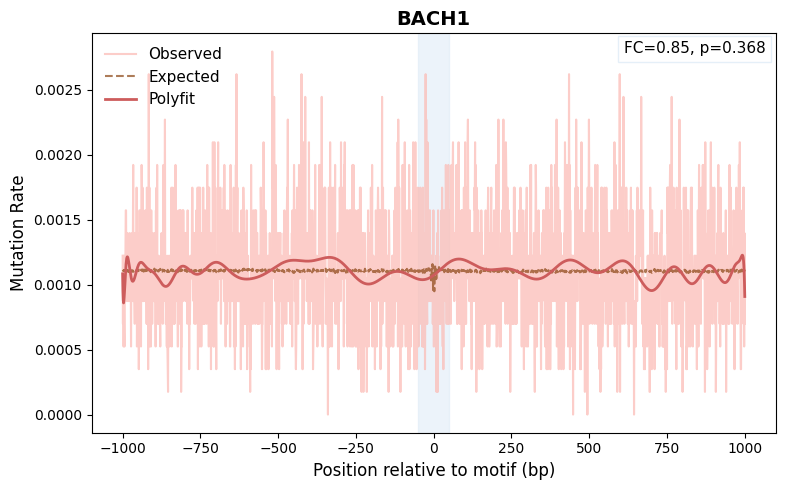

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: BHLHE40 Obs Sum: 11393 Exp Sum: 11393.000000000031
FC_core: 1.027647619391815 OR_core1.0308944600598422 Pvalue_core: 0.6206418018063804 
FC_motif: 0.7787848079606359 OR_motif0.7835634067624496 Pvalue_motif: 0.15216067682010354
FC motif:0.7787848079606359 Pvalue motif: 0.15216067682010354
FC core:1.027647619391815 Pvalue: 0.6206418018063804


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


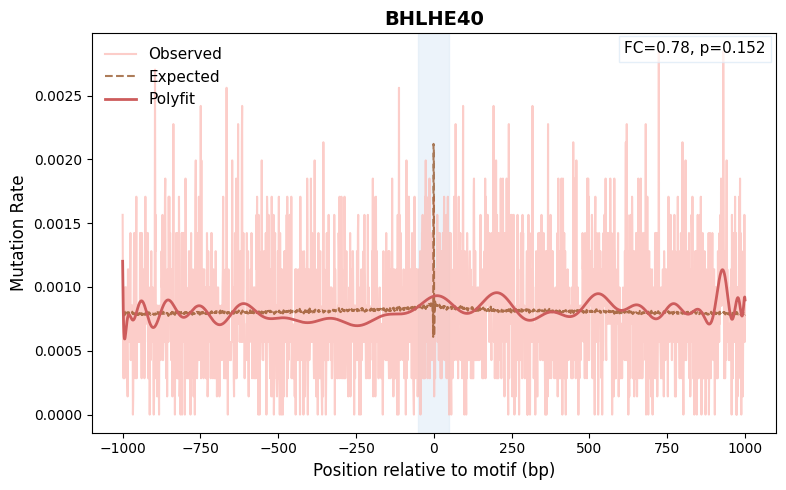

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: CEBPA Obs Sum: 37167 Exp Sum: 37167.00000000012
FC_core: 1.2572031054956894 OR_core1.2748752645643306 Pvalue_core: 2.2626601740445186e-14 
FC_motif: 1.5384081689025562 OR_motif1.547584546484438 Pvalue_motif: 1.8525634664571546e-06
FC motif:1.5384081689025562 Pvalue motif: 1.8525634664571546e-06
FC core:1.2572031054956894 Pvalue: 2.2626601740445186e-14


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


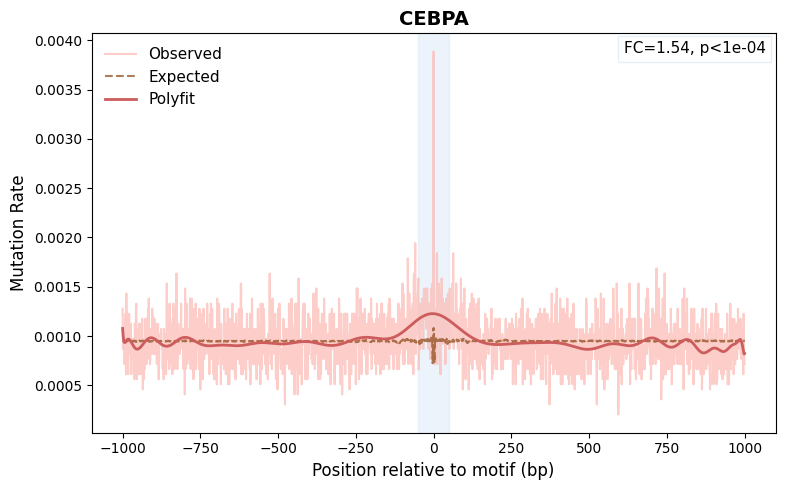

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: CEBPB Obs Sum: 46621 Exp Sum: 46621.000000000146
FC_core: 1.2654008372610617 OR_core1.2840638970973612 Pvalue_core: 1.0468815315722114e-18 
FC_motif: 1.9491362609168201 OR_motif1.9640897755610973 Pvalue_motif: 2.075711867651612e-19
FC motif:1.9491362609168201 Pvalue motif: 2.075711867651612e-19
FC core:1.2654008372610617 Pvalue: 1.0468815315722114e-18


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


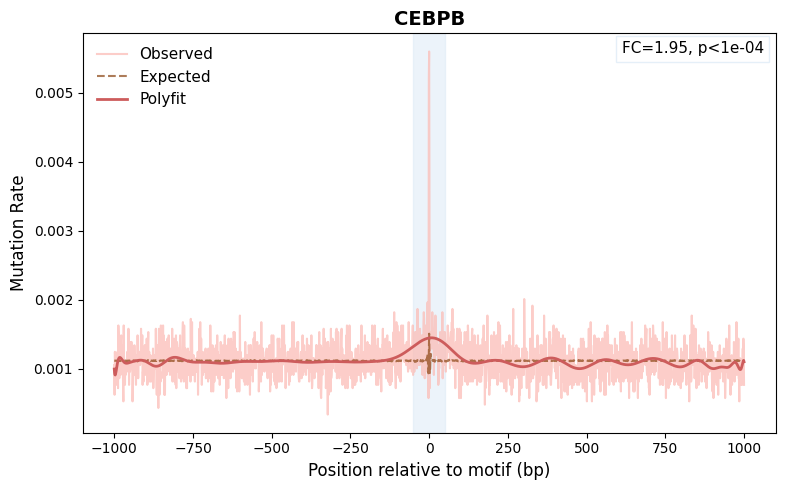

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: CEBPD Obs Sum: 3937 Exp Sum: 3937.000000000012
FC_core: 1.6053964483653902 OR_core1.66753295719268 Pvalue_core: 2.066216612678698e-08 
FC_motif: 1.3623712085787159 OR_motif1.4119769119769119 Pvalue_motif: 0.2700569817461417
FC motif:1.3623712085787159 Pvalue motif: 0.2700569817461417
FC core:1.6053964483653902 Pvalue: 2.066216612678698e-08


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


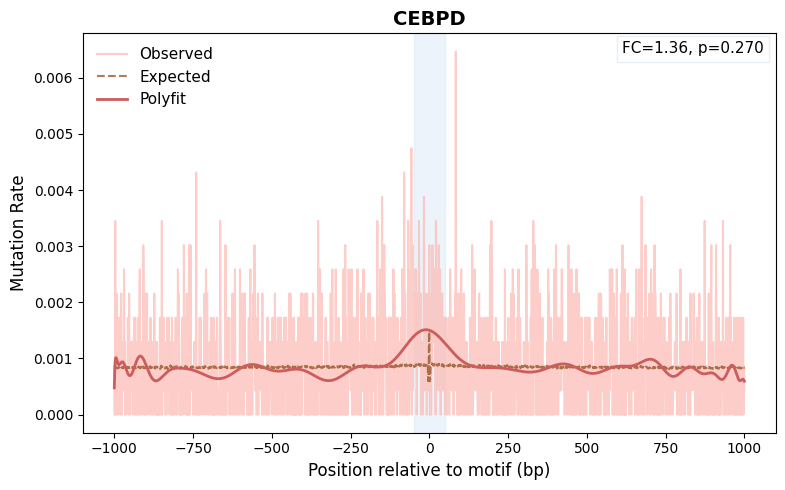

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: CEBPG Obs Sum: 25749 Exp Sum: 25749.000000000084
FC_core: 1.4664176600464702 OR_core1.5045451364100841 Pvalue_core: 5.926201737813954e-29 
FC_motif: 2.88749892248209 OR_motif2.9369642303852377 Pvalue_motif: 1.1834113687043103e-34
FC motif:2.88749892248209 Pvalue motif: 1.1834113687043103e-34
FC core:1.4664176600464702 Pvalue: 5.926201737813954e-29


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


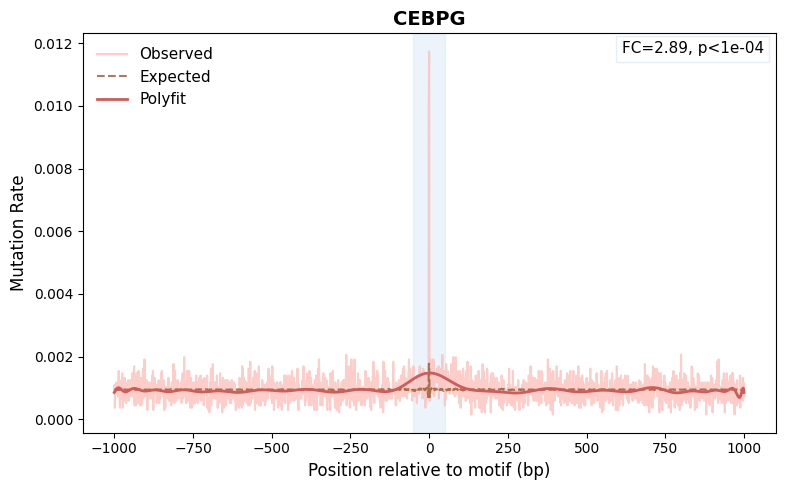

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: CREB1 Obs Sum: 11404 Exp Sum: 11404.000000000036
FC_core: 1.2244533328456533 OR_core1.241248799125432 Pvalue_core: 0.00012756736730257343 
FC_motif: 1.0211799862897237 OR_motif1.0250905317081789 Pvalue_motif: 0.937185462339523
FC motif:1.0211799862897237 Pvalue motif: 0.937185462339523
FC core:1.2244533328456533 Pvalue: 0.00012756736730257343


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


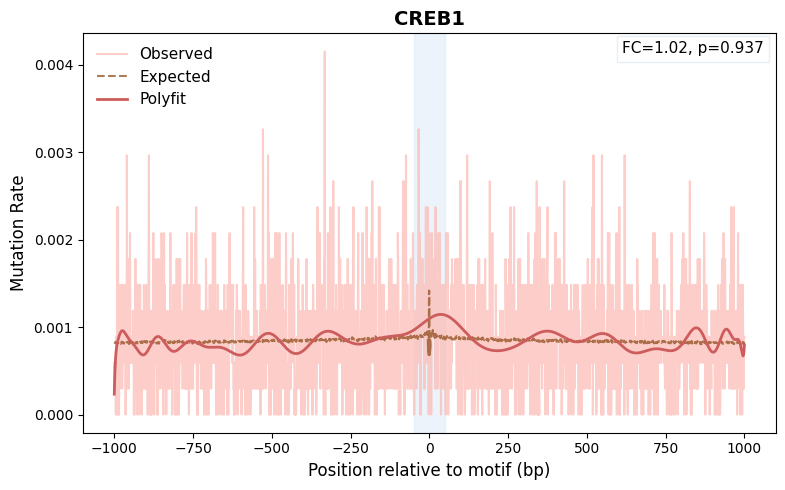

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: CREM Obs Sum: 7598 Exp Sum: 7598.000000000026
FC_core: 1.0768531817517075 OR_core1.0823397053993828 Pvalue_core: 0.275386505808936 
FC_motif: 1.2900757453058003 OR_motif1.2992272848387956 Pvalue_motif: 0.11498933918811358
FC motif:1.2900757453058003 Pvalue motif: 0.11498933918811358
FC core:1.0768531817517075 Pvalue: 0.275386505808936


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


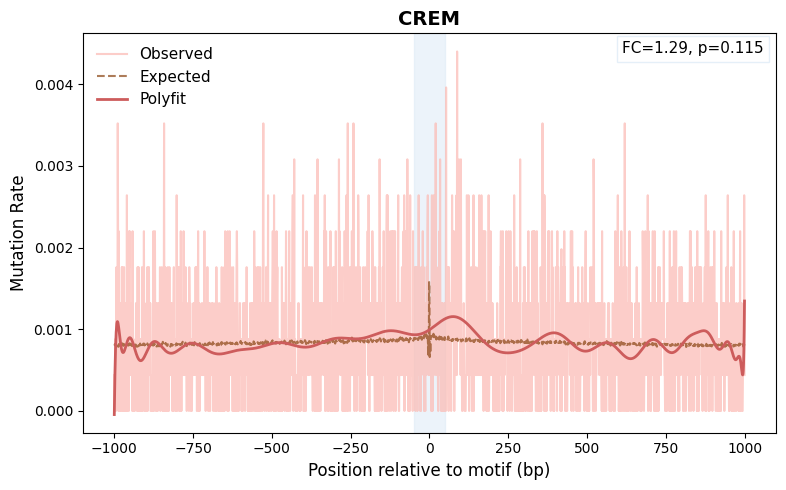

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: CTCF Obs Sum: 91972 Exp Sum: 91972.00000000023
FC_core: 1.575022472487924 OR_core1.6267250563142355 Pvalue_core: 8.847315080263166e-147 
FC_motif: 2.7301721505135723 OR_motif2.783221133595631 Pvalue_motif: 1.5811096584529324e-178
FC motif:2.7301721505135723 Pvalue motif: 1.5811096584529324e-178
FC core:1.575022472487924 Pvalue: 8.847315080263166e-147


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


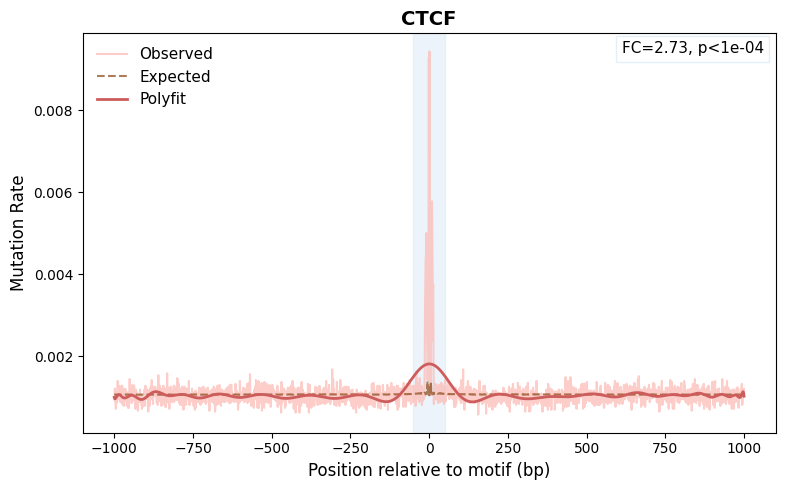

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: ELF3 Obs Sum: 13294 Exp Sum: 13294.00000000005
FC_core: 1.101213291279041 OR_core1.1074402347161436 Pvalue_core: 0.06053944765791986 
FC_motif: 0.9269430775195029 OR_motif0.9313244846282993 Pvalue_motif: 0.6454174024103789
FC motif:0.9269430775195029 Pvalue motif: 0.6454174024103789
FC core:1.101213291279041 Pvalue: 0.06053944765791986


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


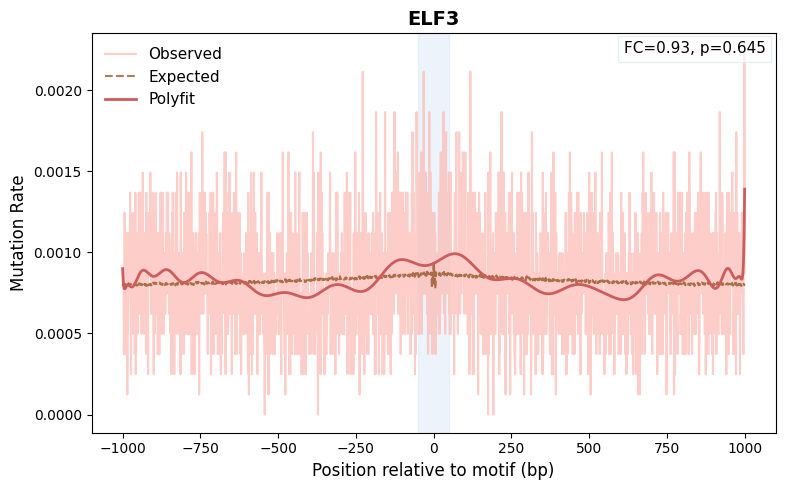

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: ETV4 Obs Sum: 10853 Exp Sum: 10853.000000000036
FC_core: 1.0207597567741815 OR_core1.0225981079535176 Pvalue_core: 0.7366014584276529 
FC_motif: 1.071459044598014 OR_motif1.0881224932407936 Pvalue_motif: 0.7132719504865715
FC motif:1.071459044598014 Pvalue motif: 0.7132719504865715
FC core:1.0207597567741815 Pvalue: 0.7366014584276529


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


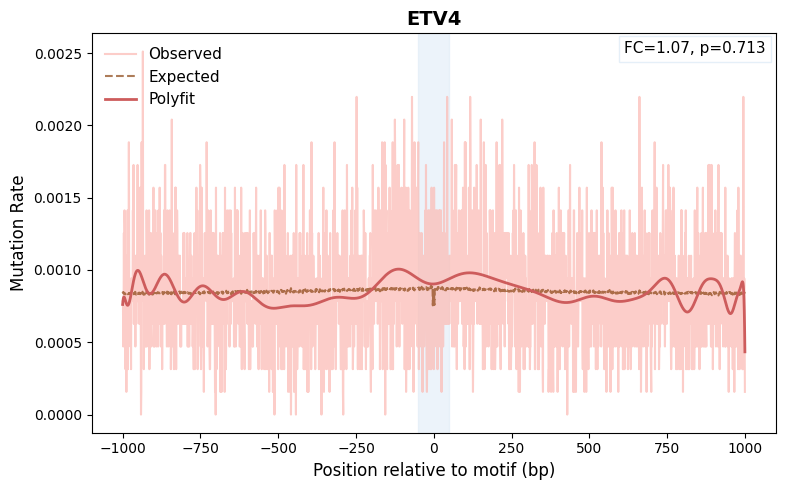

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: FOS Obs Sum: 6623 Exp Sum: 6623.000000000017
FC_core: 1.2500896931945344 OR_core1.2684348158045429 Pvalue_core: 0.0016944742929337173 
FC_motif: 1.1054389151613668 OR_motif1.1147934386391252 Pvalue_motif: 0.7268102724151135
FC motif:1.1054389151613668 Pvalue motif: 0.7268102724151135
FC core:1.2500896931945344 Pvalue: 0.0016944742929337173


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


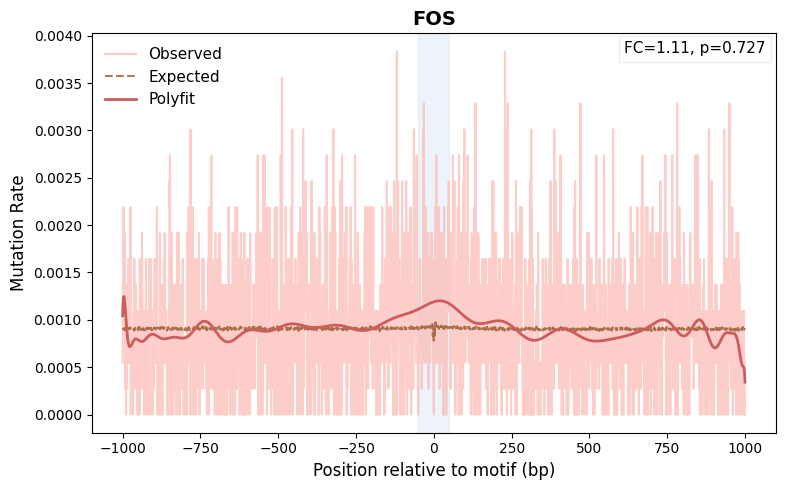

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: FOSL2 Obs Sum: 32839 Exp Sum: 32839.0000000001
FC_core: 1.0994698887185086 OR_core1.1058299677250234 Pvalue_core: 0.003967190177164295 
FC_motif: 0.9947167310178818 OR_motif0.999969384318648 Pvalue_motif: 1.0
FC motif:0.9947167310178818 Pvalue motif: 1.0
FC core:1.0994698887185086 Pvalue: 0.003967190177164295


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


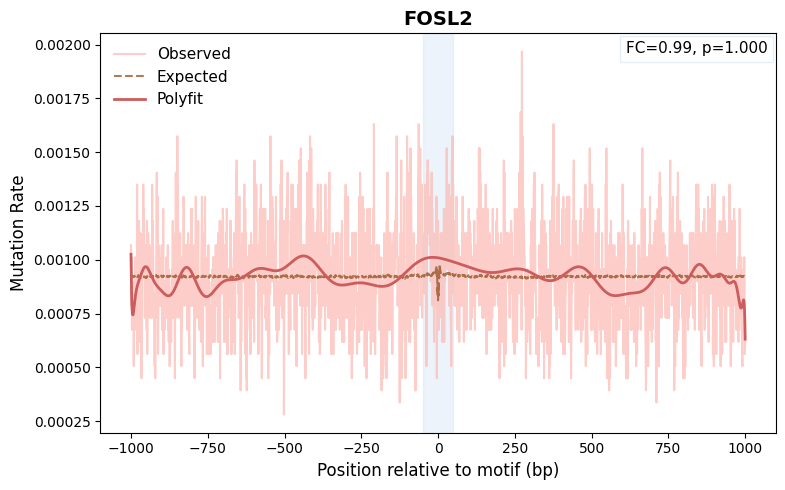

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: FOXA1 Obs Sum: 44216 Exp Sum: 44216.00000000011
FC_core: 1.210491316496996 OR_core1.2245103254957013 Pvalue_core: 7.372360725862224e-12 
FC_motif: 1.1253325744228717 OR_motif1.1273887336522548 Pvalue_motif: 0.21171553004858953
FC motif:1.1253325744228717 Pvalue motif: 0.21171553004858953
FC core:1.210491316496996 Pvalue: 7.372360725862224e-12


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


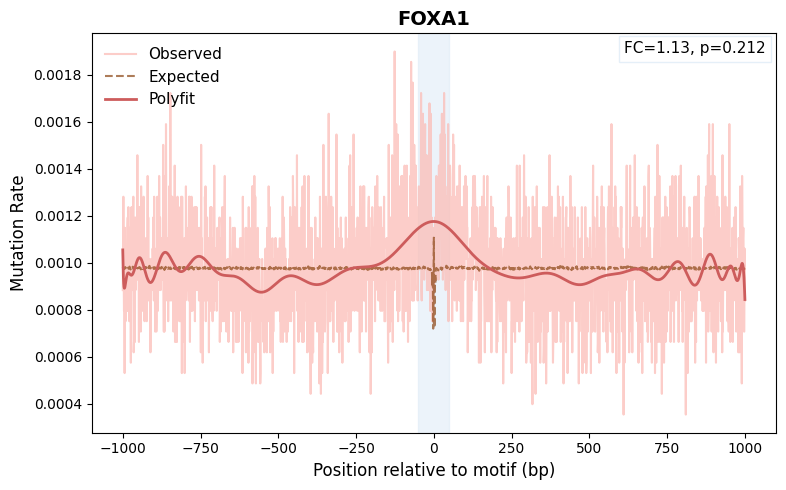

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: FOXA2 Obs Sum: 22509 Exp Sum: 22509.000000000055
FC_core: 1.2657129698727299 OR_core1.2846341976161129 Pvalue_core: 9.778720913071655e-10 
FC_motif: 1.2447545358815315 OR_motif1.2494256576893075 Pvalue_motif: 0.08314802833916837
FC motif:1.2447545358815315 Pvalue motif: 0.08314802833916837
FC core:1.2657129698727299 Pvalue: 9.778720913071655e-10


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


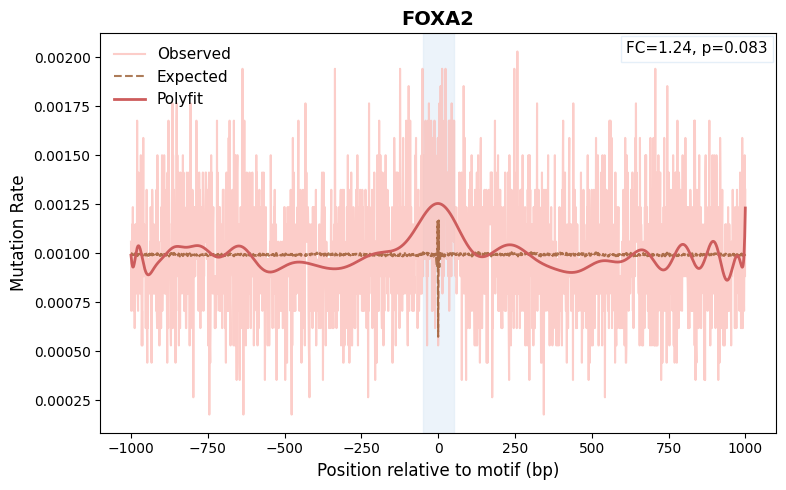

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: FOXA3 Obs Sum: 22323 Exp Sum: 22323.00000000006
FC_core: 1.224459533163546 OR_core1.2392236654008402 Pvalue_core: 2.1660752614104e-07 
FC_motif: 1.3037882184278866 OR_motif1.3063479084432887 Pvalue_motif: 0.035989486642444196
FC motif:1.3037882184278866 Pvalue motif: 0.035989486642444196
FC core:1.224459533163546 Pvalue: 2.1660752614104e-07


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


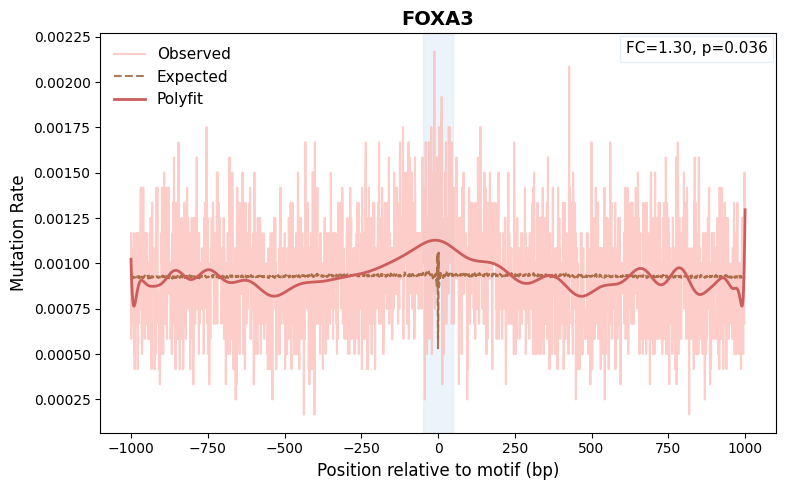

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: FOXK1 Obs Sum: 6414 Exp Sum: 6414.000000000022
FC_core: 1.459349907445068 OR_core1.5001581017865502 Pvalue_core: 4.208700800314366e-08 
FC_motif: 1.5808344004845991 OR_motif1.606559444970041 Pvalue_motif: 0.015391529200393174
FC motif:1.5808344004845991 Pvalue motif: 0.015391529200393174
FC core:1.459349907445068 Pvalue: 4.208700800314366e-08


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


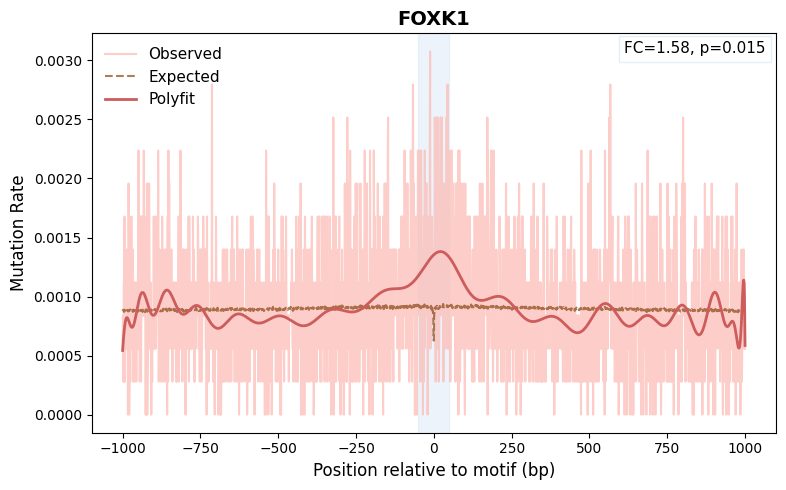

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: FOXP1 Obs Sum: 20642 Exp Sum: 20642.00000000006
FC_core: 1.3213105039859845 OR_core1.3441796404670567 Pvalue_core: 5.555451610020931e-12 
FC_motif: 1.0919081711098864 OR_motif1.0958256693235233 Pvalue_motif: 0.49709790436016815
FC motif:1.0919081711098864 Pvalue motif: 0.49709790436016815
FC core:1.3213105039859845 Pvalue: 5.555451610020931e-12


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


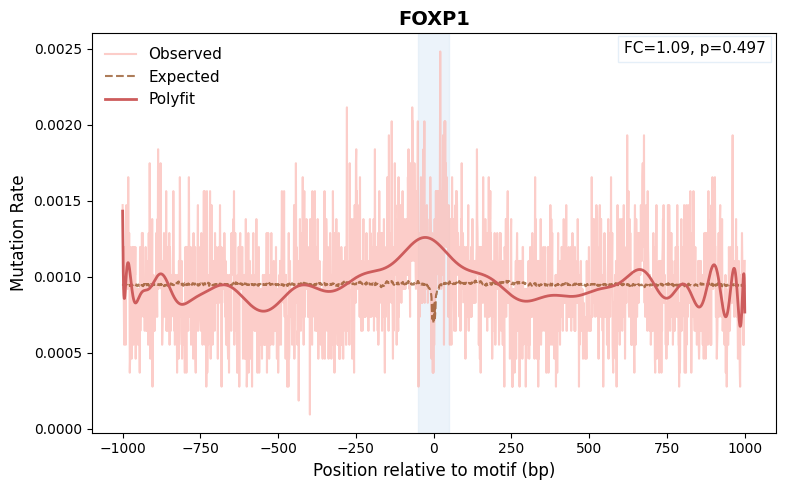

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: GABPA Obs Sum: 14922 Exp Sum: 14922.000000000051
FC_core: 1.0406427819132602 OR_core1.0435635183448289 Pvalue_core: 0.41565067117851334 
FC_motif: 0.8374964108586571 OR_motif0.8400595733738244 Pvalue_motif: 0.2714699747880065
FC motif:0.8374964108586571 Pvalue motif: 0.2714699747880065
FC core:1.0406427819132602 Pvalue: 0.41565067117851334


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


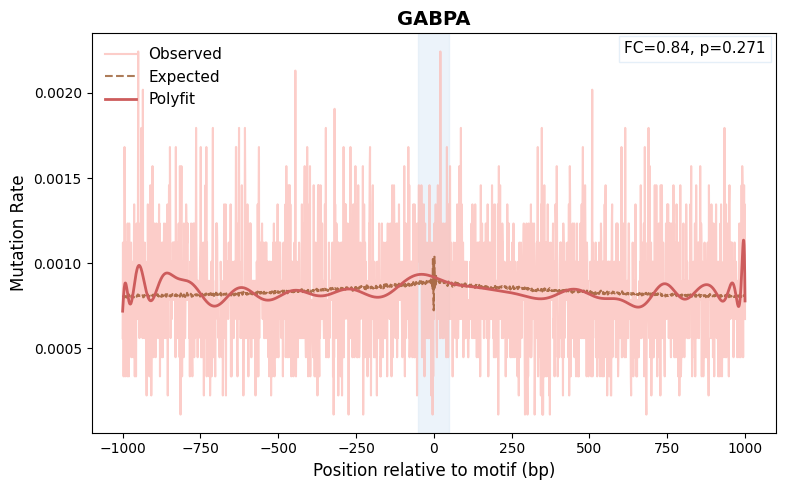

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: GATA4 Obs Sum: 2709 Exp Sum: 2709.0000000000077
FC_core: 1.2650440195901238 OR_core1.2881095322420422 Pvalue_core: 0.03534965420749825 
FC_motif: 1.101119955516643 OR_motif1.1180625410015308 Pvalue_motif: 0.8674985032041536
FC motif:1.101119955516643 Pvalue motif: 0.8674985032041536
FC core:1.2650440195901238 Pvalue: 0.03534965420749825


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


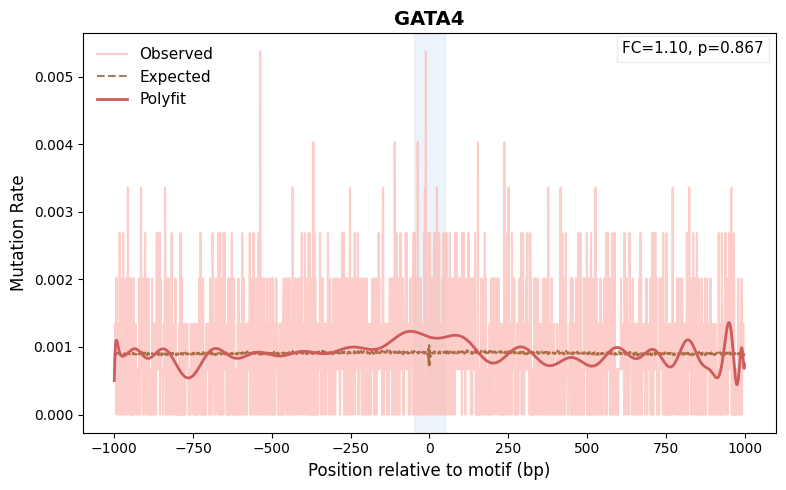

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: HLF Obs Sum: 95518 Exp Sum: 95518.00000000029
FC_core: 1.0172321456800797 OR_core1.0183796529890745 Pvalue_core: 0.3844653140430427 
FC_motif: 1.3136343071591656 OR_motif1.3171741322368937 Pvalue_motif: 9.748775692113599e-08
FC motif:1.3136343071591656 Pvalue motif: 9.748775692113599e-08
FC core:1.0172321456800797 Pvalue: 0.3844653140430427


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


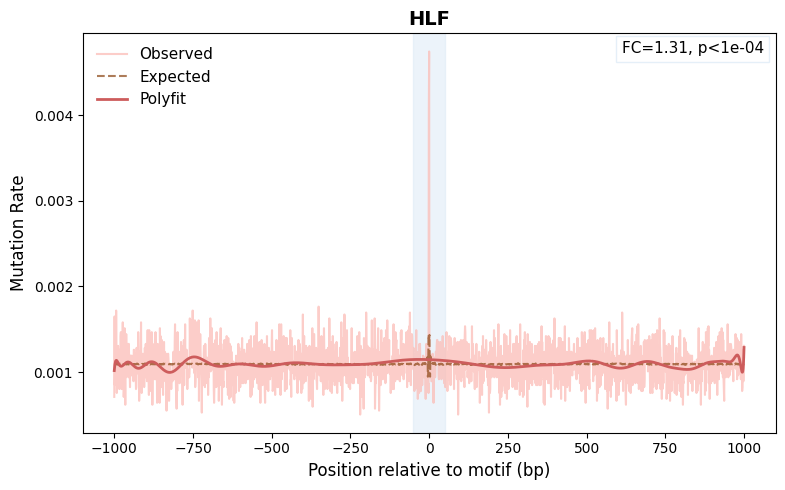

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: HNF1A Obs Sum: 13778 Exp Sum: 13778.00000000004
FC_core: 1.3989782658332155 OR_core1.4292219350794504 Pvalue_core: 3.545636448000232e-12 
FC_motif: 1.2314510544559365 OR_motif1.2391061165768185 Pvalue_motif: 0.13359378329649396
FC motif:1.2314510544559365 Pvalue motif: 0.13359378329649396
FC core:1.3989782658332155 Pvalue: 3.545636448000232e-12


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


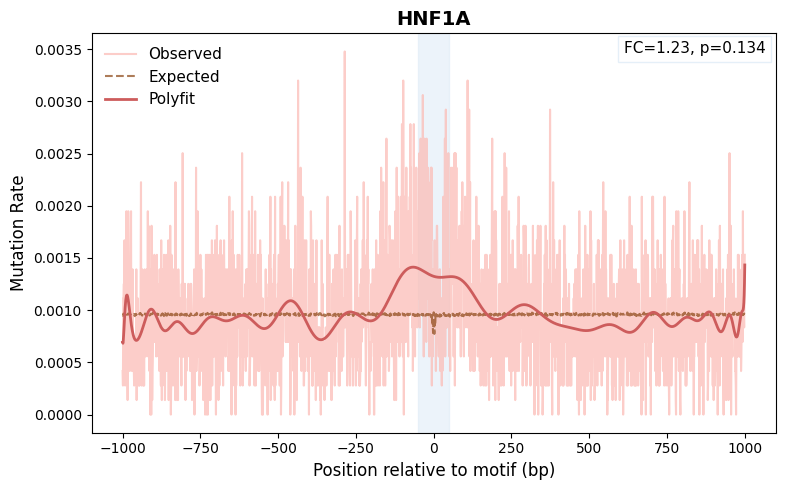

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: HNF4A Obs Sum: 29602 Exp Sum: 29602.00000000006
FC_core: 1.3266591782005923 OR_core1.3506976769934307 Pvalue_core: 1.415350268263748e-17 
FC_motif: 1.2498228628324053 OR_motif1.2569838205103139 Pvalue_motif: 0.01484765427216052
FC motif:1.2498228628324053 Pvalue motif: 0.01484765427216052
FC core:1.3266591782005923 Pvalue: 1.415350268263748e-17


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


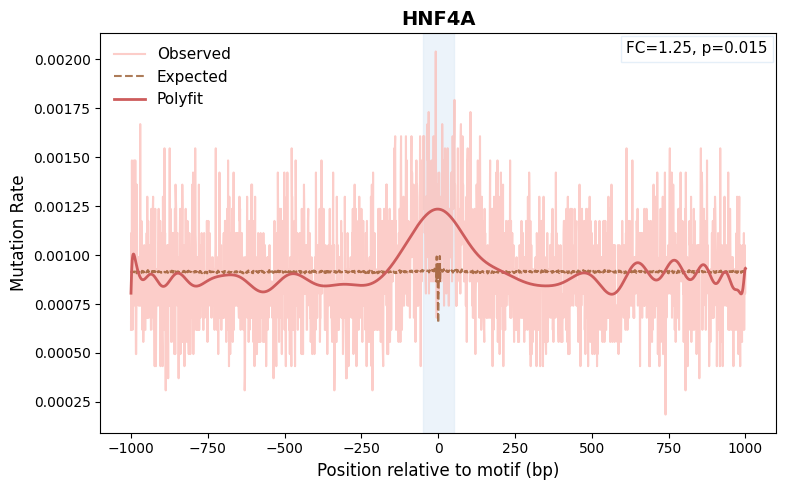

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: HNF4G Obs Sum: 24414 Exp Sum: 24414.000000000062
FC_core: 1.370074655696182 OR_core1.3981728779800997 Pvalue_core: 3.1508642451989167e-18 
FC_motif: 1.1298281095240064 OR_motif1.1324564632592382 Pvalue_motif: 0.25280225329742023
FC motif:1.1298281095240064 Pvalue motif: 0.25280225329742023
FC core:1.370074655696182 Pvalue: 3.1508642451989167e-18


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


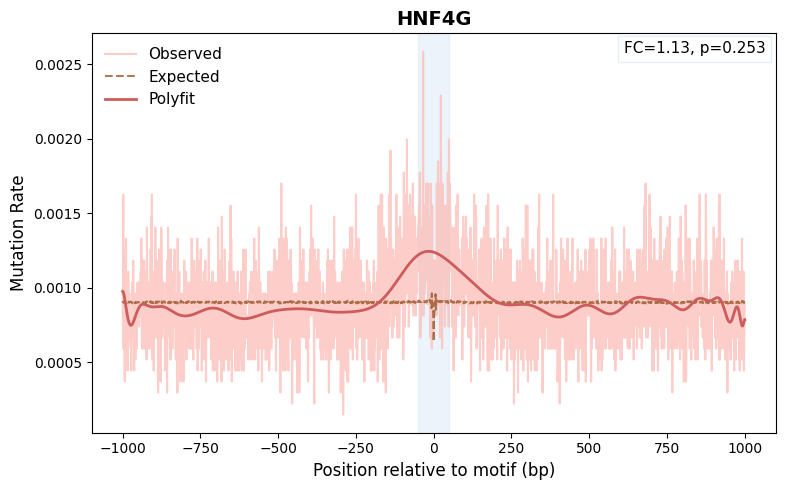

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: JUN Obs Sum: 18588 Exp Sum: 18588.000000000055
FC_core: 1.0553865080386935 OR_core1.0585549787774762 Pvalue_core: 0.23269669682312 
FC_motif: 1.1737812088883408 OR_motif1.17537836422069 Pvalue_motif: 0.18234197413317907
FC motif:1.1737812088883408 Pvalue motif: 0.18234197413317907
FC core:1.0553865080386935 Pvalue: 0.23269669682312


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


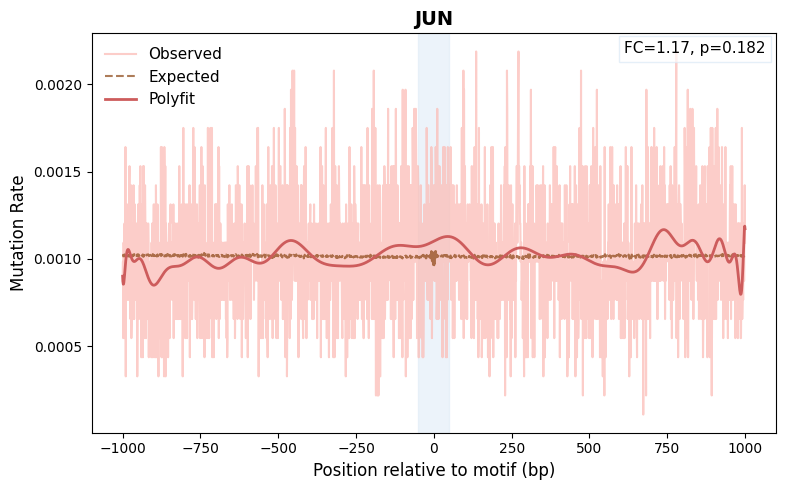

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: JUND Obs Sum: 68181 Exp Sum: 68181.0000000002
FC_core: 1.0091948569115496 OR_core1.0097723795506324 Pvalue_core: 0.7021409081654073 
FC_motif: 1.075557954085886 OR_motif1.077778400735746 Pvalue_motif: 0.3143756047383614
FC motif:1.075557954085886 Pvalue motif: 0.3143756047383614
FC core:1.0091948569115496 Pvalue: 0.7021409081654073


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


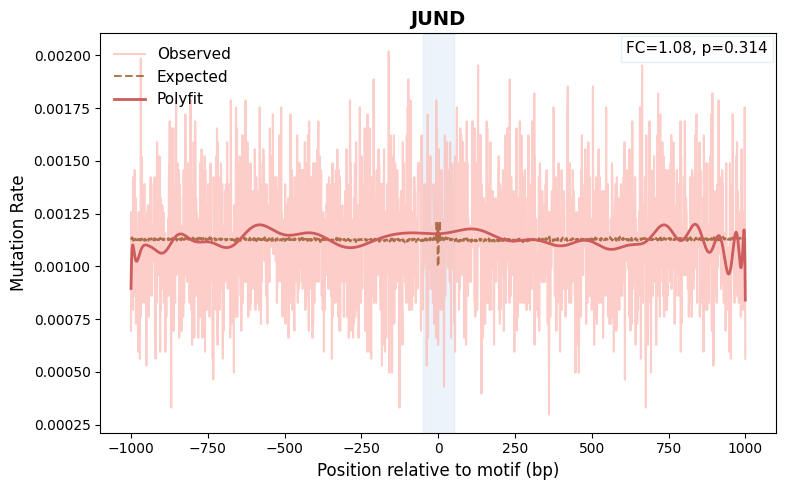

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: KLF10 Obs Sum: 4495 Exp Sum: 4495.0000000000155
FC_core: 0.8526079483377951 OR_core0.8467419833390392 Pvalue_core: 0.0800865229102207 
FC_motif: 0.8481244139274108 OR_motif0.8792130561144645 Pvalue_motif: 0.6646185059697034
FC motif:0.8481244139274108 Pvalue motif: 0.6646185059697034
FC core:0.8526079483377951 Pvalue: 0.0800865229102207


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


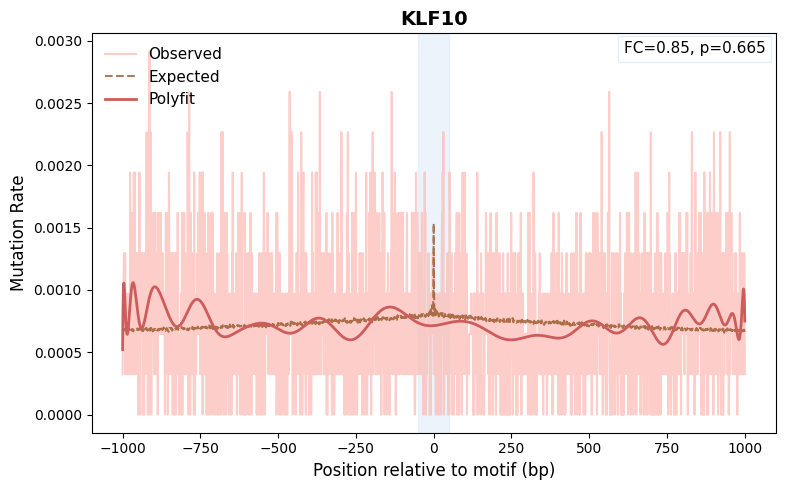

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: KLF11 Obs Sum: 3663 Exp Sum: 3663.0000000000136
FC_core: 1.0695696119118707 OR_core1.07899146564826 Pvalue_core: 0.48024662176563293 
FC_motif: 0.776068476970316 OR_motif0.790363154043176 Pvalue_motif: 0.4500094559655997
FC motif:0.776068476970316 Pvalue motif: 0.4500094559655997
FC core:1.0695696119118707 Pvalue: 0.48024662176563293


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


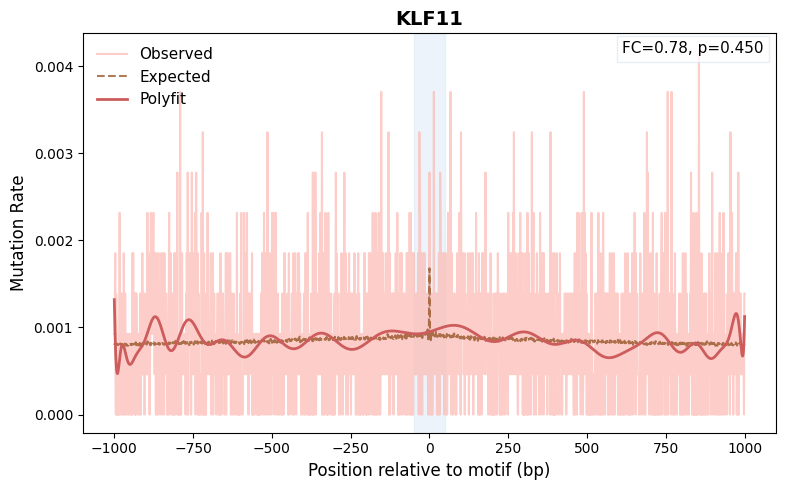

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: KLF16 Obs Sum: 11879 Exp Sum: 11879.000000000031
FC_core: 0.9151050700151074 OR_core0.9112273642288128 Pvalue_core: 0.11022339954900676 
FC_motif: 0.6277317623486353 OR_motif0.62661204673039 Pvalue_motif: 0.009890295718785184
FC motif:0.6277317623486353 Pvalue motif: 0.009890295718785184
FC core:0.9151050700151074 Pvalue: 0.11022339954900676


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


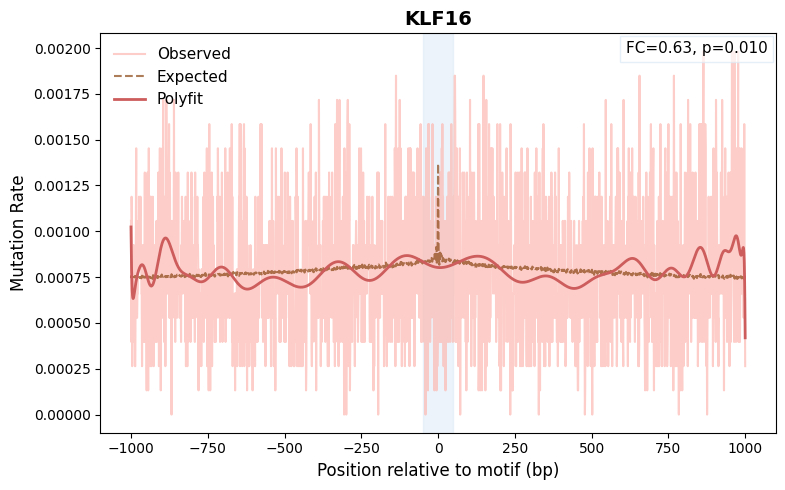

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: KLF6 Obs Sum: 3533 Exp Sum: 3533.000000000012
FC_core: 1.0364636987460294 OR_core1.0430048859435634 Pvalue_core: 0.718630528905986 
FC_motif: 0.6693419112516188 OR_motif0.6940697976289081 Pvalue_motif: 0.26682476413644474
FC motif:0.6693419112516188 Pvalue motif: 0.26682476413644474
FC core:1.0364636987460294 Pvalue: 0.718630528905986


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


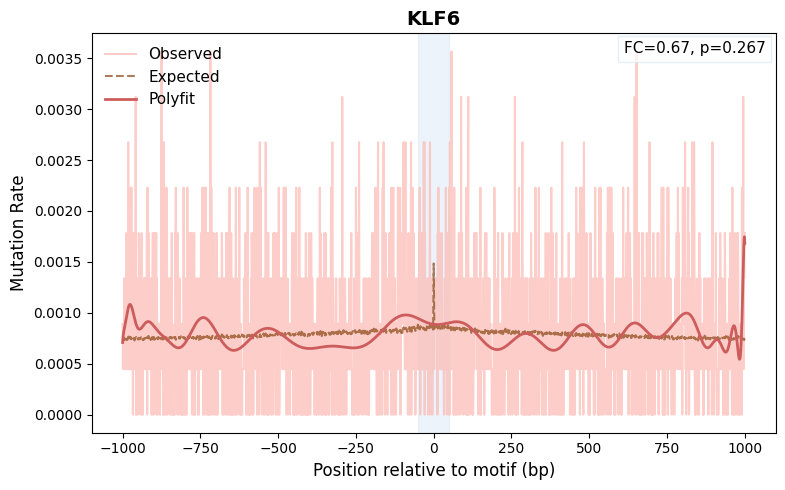

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: MAFF Obs Sum: 97473 Exp Sum: 97473.00000000032
FC_core: 1.024924727770762 OR_core1.0263295572466276 Pvalue_core: 0.2135747713374163 
FC_motif: 0.9404940774208442 OR_motif0.9407322229812504 Pvalue_motif: 0.18718521709838096
FC motif:0.9404940774208442 Pvalue motif: 0.18718521709838096
FC core:1.024924727770762 Pvalue: 0.2135747713374163


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


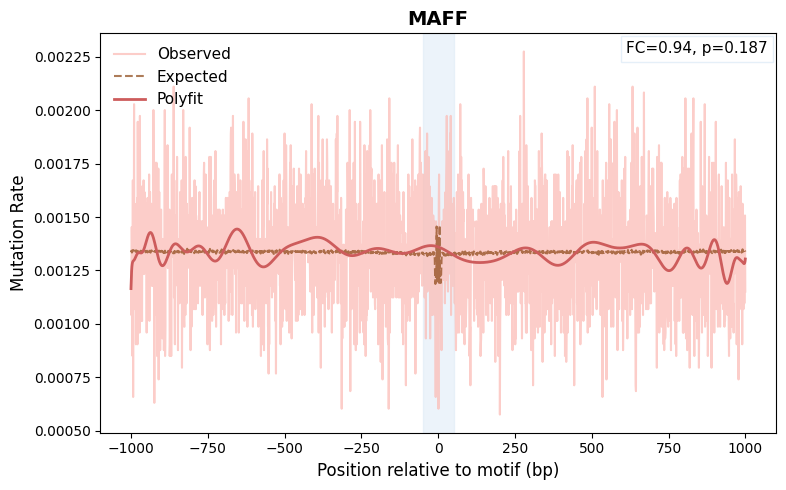

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: MAFK Obs Sum: 126956 Exp Sum: 126956.0000000003
FC_core: 1.0162590699297873 OR_core1.0172143223112318 Pvalue_core: 0.35306578843601893 
FC_motif: 1.0058621849252345 OR_motif1.006684449588453 Pvalue_motif: 0.9061656353860693
FC motif:1.0058621849252345 Pvalue motif: 0.9061656353860693
FC core:1.0162590699297873 Pvalue: 0.35306578843601893


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


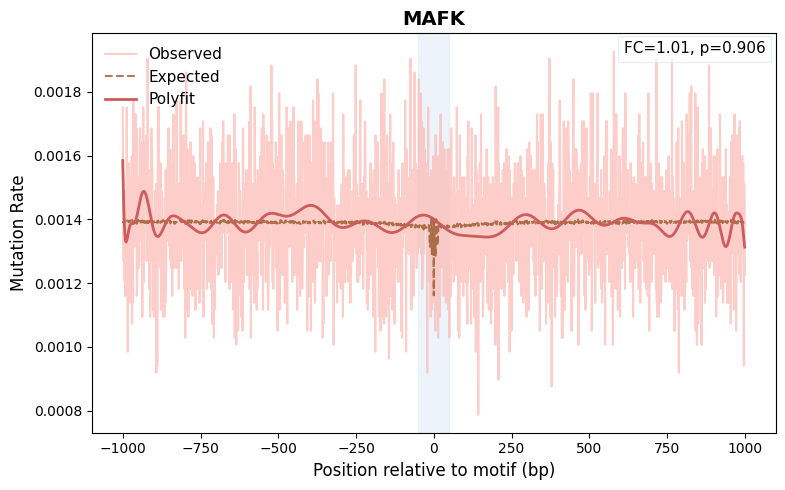

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: MAX Obs Sum: 8460 Exp Sum: 8460.000000000025
FC_core: 1.0490844398708081 OR_core1.0530046953741525 Pvalue_core: 0.4605338540257089 
FC_motif: 0.9443950303631641 OR_motif0.9469176152372366 Pvalue_motif: 0.7762405547215077
FC motif:0.9443950303631641 Pvalue motif: 0.7762405547215077
FC core:1.0490844398708081 Pvalue: 0.4605338540257089


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


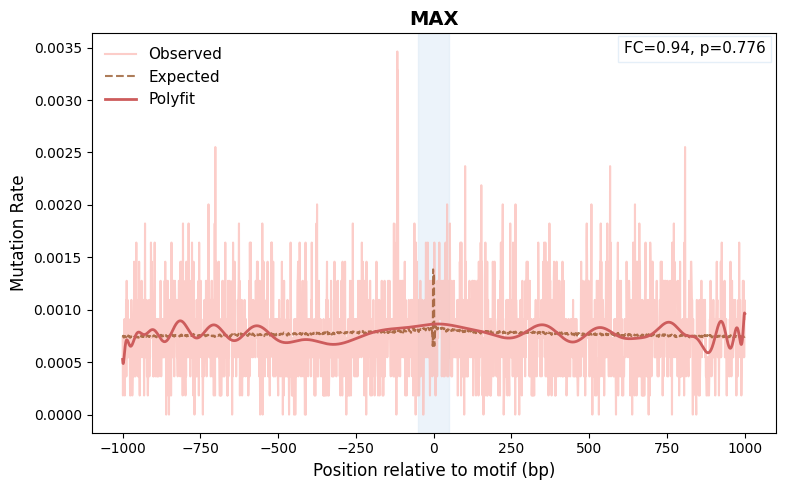

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: MAZ Obs Sum: 5790 Exp Sum: 5790.000000000018
FC_core: 0.797962705711624 OR_core0.7906035417419588 Pvalue_core: 0.006225939152138303 
FC_motif: 0.8191902198601857 OR_motif0.8205739552627016 Pvalue_motif: 0.48747180384460875
FC motif:0.8191902198601857 Pvalue motif: 0.48747180384460875
FC core:0.797962705711624 Pvalue: 0.006225939152138303


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


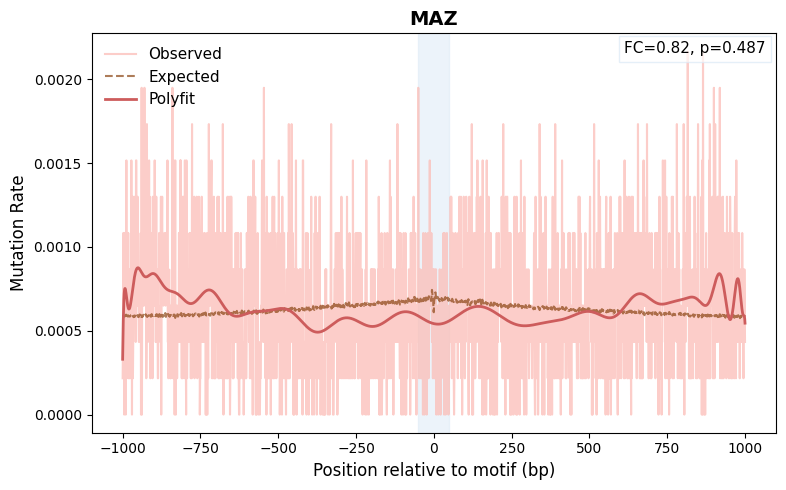

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: MIXL1 Obs Sum: 10838 Exp Sum: 10838.000000000033
FC_core: 1.299824210589696 OR_core1.3220961117330907 Pvalue_core: 2.1893680441979616e-06 
FC_motif: 1.6264889502670457 OR_motif1.6702232943650646 Pvalue_motif: 0.018176630521541115
FC motif:1.6264889502670457 Pvalue motif: 0.018176630521541115
FC core:1.299824210589696 Pvalue: 2.1893680441979616e-06


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


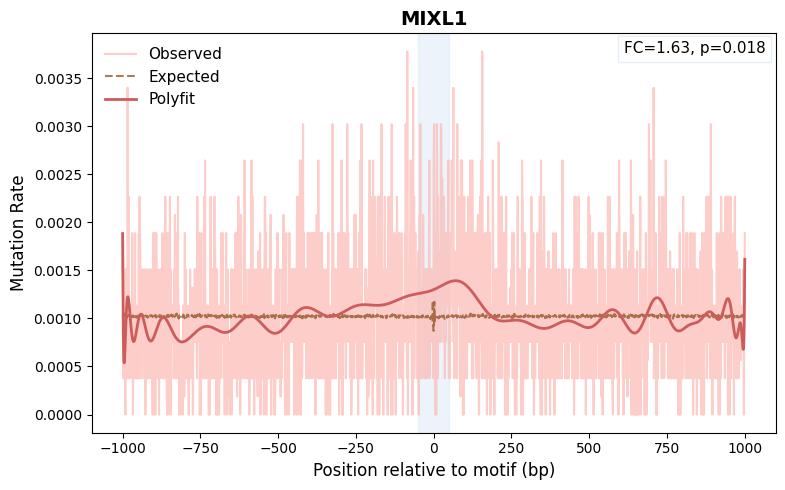

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: MLX Obs Sum: 3183 Exp Sum: 3183.0000000000086
FC_core: 1.0660571991978096 OR_core1.072888980934958 Pvalue_core: 0.5506452670917632 
FC_motif: 0.6988693691514534 OR_motif0.7127074314574314 Pvalue_motif: 0.3225917231075014
FC motif:0.6988693691514534 Pvalue motif: 0.3225917231075014
FC core:1.0660571991978096 Pvalue: 0.5506452670917632


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


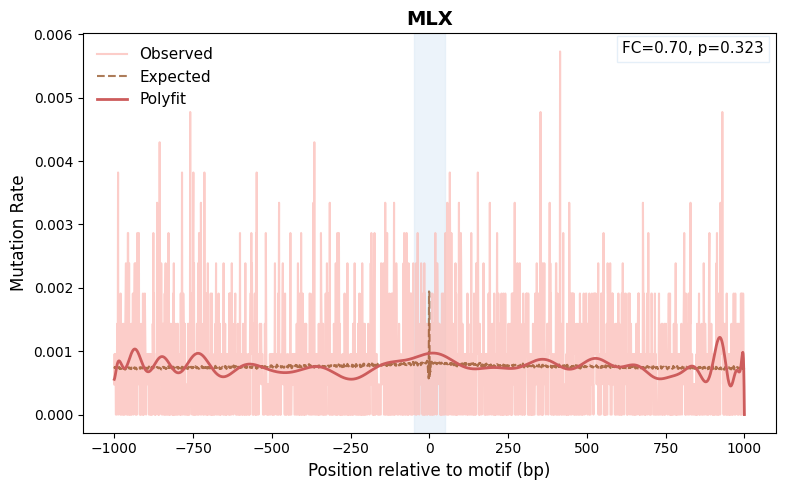

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: MXI1 Obs Sum: 3029 Exp Sum: 3029.000000000008
FC_core: 1.0533556607980046 OR_core1.0588552223663314 Pvalue_core: 0.6511487153621682 
FC_motif: 0.9322414162531519 OR_motif0.9996687644915535 Pvalue_motif: 1.0
FC motif:0.9322414162531519 Pvalue motif: 1.0
FC core:1.0533556607980046 Pvalue: 0.6511487153621682


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


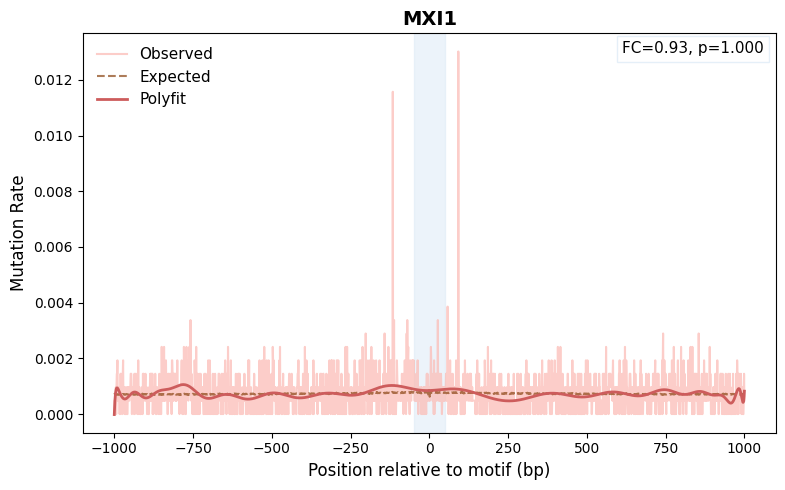

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: MYBL2 Obs Sum: 1220 Exp Sum: 1220.0000000000039
FC_core: 0.9744107254504553 OR_core0.9819106840022611 Pvalue_core: 0.9260384398208115 
FC_motif: 0.6494557305829373 OR_motif0.6644700713893466 Pvalue_motif: 0.4529900509320044
FC motif:0.6494557305829373 Pvalue motif: 0.4529900509320044
FC core:0.9744107254504553 Pvalue: 0.9260384398208115


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


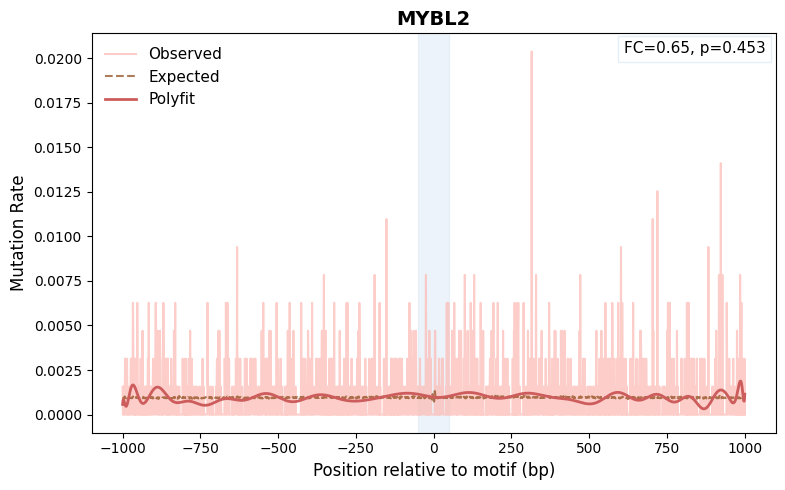

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: NFE2L2 Obs Sum: 12610 Exp Sum: 12610.000000000042
FC_core: 1.0031004696932284 OR_core1.0032383518654244 Pvalue_core: 0.9770294039843719 
FC_motif: 1.070709474040974 OR_motif1.073871927330396 Pvalue_motif: 0.7356424345247528
FC motif:1.070709474040974 Pvalue motif: 0.7356424345247528
FC core:1.0031004696932284 Pvalue: 0.9770294039843719


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


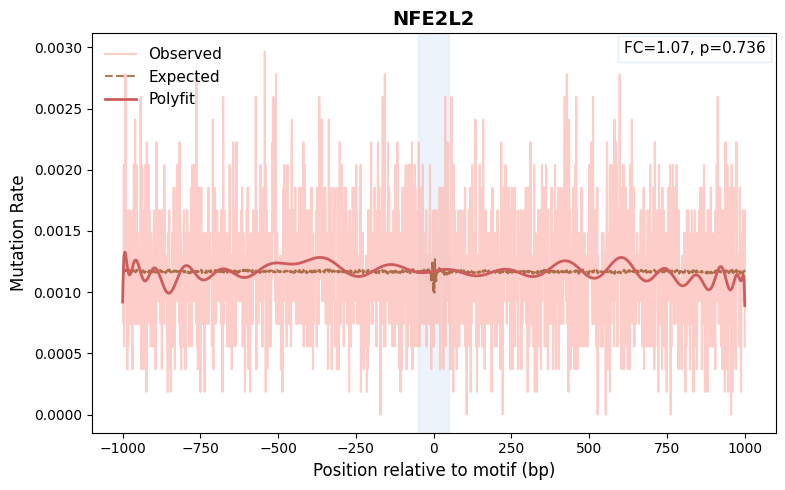

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: NFIA Obs Sum: 12320 Exp Sum: 12320.000000000036
FC_core: 1.975299856421769 OR_core2.0838443789045953 Pvalue_core: 2.2296334532762317e-49 
FC_motif: 2.477831869045583 OR_motif2.5373987232997792 Pvalue_motif: 2.664128127311152e-07
FC motif:2.477831869045583 Pvalue motif: 2.664128127311152e-07
FC core:1.975299856421769 Pvalue: 2.2296334532762317e-49


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


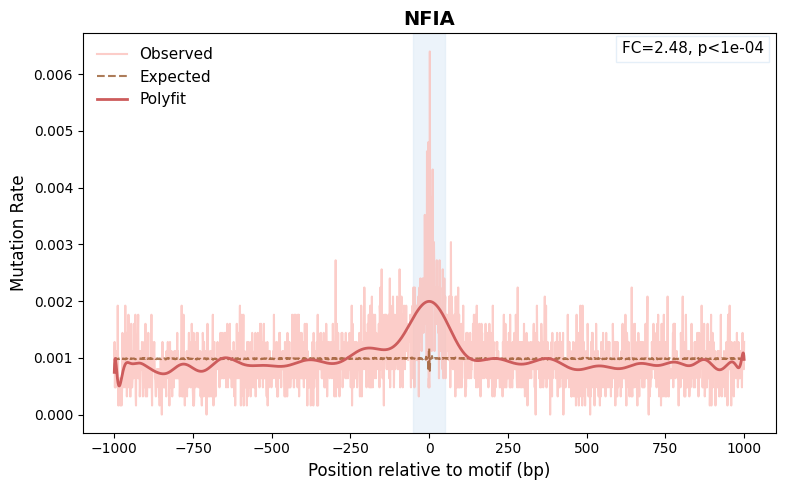

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: NFIC Obs Sum: 7699 Exp Sum: 7699.000000000022
FC_core: 1.8577021712852502 OR_core1.950010297893971 Pvalue_core: 7.410654545033544e-26 
FC_motif: 2.3192896236656004 OR_motif2.355521873596356 Pvalue_motif: 1.80624798309189e-09
FC motif:2.3192896236656004 Pvalue motif: 1.80624798309189e-09
FC core:1.8577021712852502 Pvalue: 7.410654545033544e-26


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


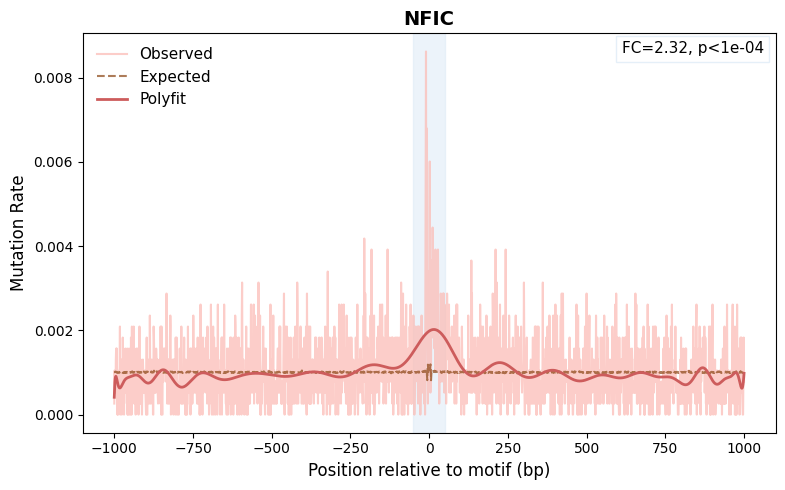

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: NFIL3 Obs Sum: 13647 Exp Sum: 13647.000000000047
FC_core: 1.2336321717216505 OR_core1.2492944047822097 Pvalue_core: 2.4794407587488784e-05 
FC_motif: 1.3433928088389213 OR_motif1.3474263558249955 Pvalue_motif: 0.03789486427764628
FC motif:1.3433928088389213 Pvalue motif: 0.03789486427764628
FC core:1.2336321717216505 Pvalue: 2.4794407587488784e-05


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


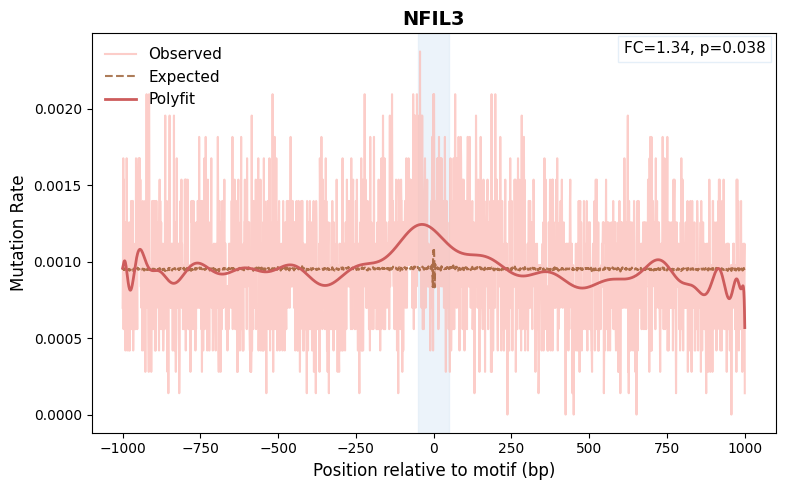

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: NFYC Obs Sum: 15760 Exp Sum: 15760.000000000053
FC_core: 1.0458479290223364 OR_core1.048543978278725 Pvalue_core: 0.3619229188913591 
FC_motif: 1.0840619832930054 OR_motif1.0868356871419658 Pvalue_motif: 0.6436501025773984
FC motif:1.0840619832930054 Pvalue motif: 0.6436501025773984
FC core:1.0458479290223364 Pvalue: 0.3619229188913591


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


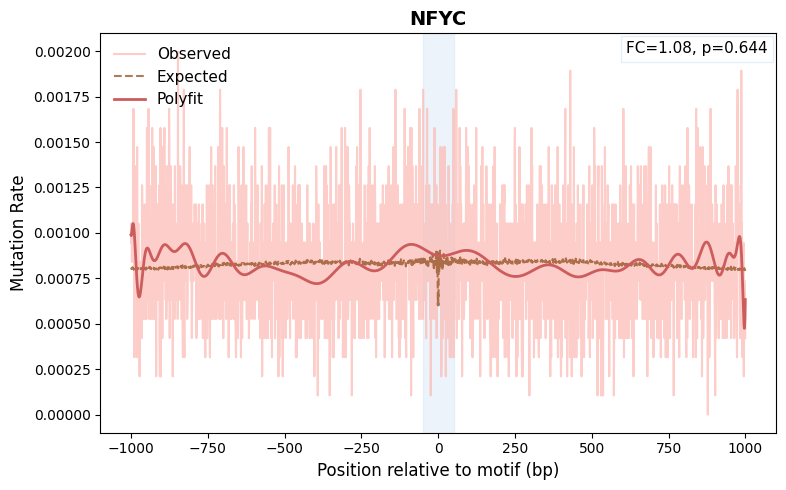

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: NR2F1 Obs Sum: 7926 Exp Sum: 7926.00000000002
FC_core: 1.1387577079011248 OR_core1.1500007644248633 Pvalue_core: 0.049896165668747494 
FC_motif: 1.001414449472395 OR_motif1.02 Pvalue_motif: 1.0
FC motif:1.001414449472395 Pvalue motif: 1.0
FC core:1.1387577079011248 Pvalue: 0.049896165668747494


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


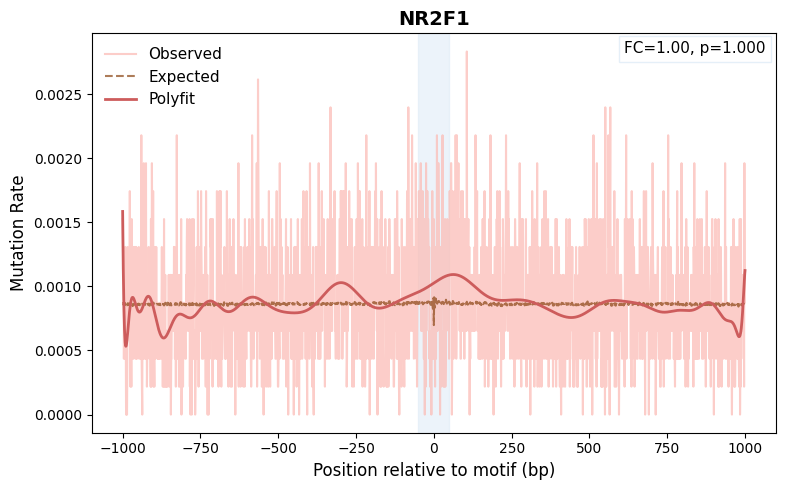

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: NR2F2 Obs Sum: 6733 Exp Sum: 6733.00000000002
FC_core: 1.1263140224824149 OR_core1.1346722087252024 Pvalue_core: 0.10736055504999838 
FC_motif: 0.9512641372572676 OR_motif0.9711385494636726 Pvalue_motif: 0.9047265842183255
FC motif:0.9512641372572676 Pvalue motif: 0.9047265842183255
FC core:1.1263140224824149 Pvalue: 0.10736055504999838


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


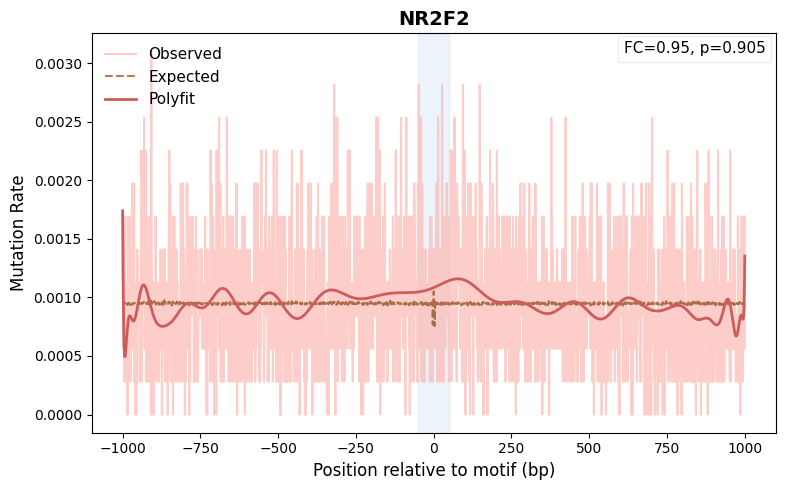

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: NR2F6 Obs Sum: 7518 Exp Sum: 7518.000000000022
FC_core: 1.2403592301206172 OR_core1.2596982782652264 Pvalue_core: 0.0011999041630111052 
FC_motif: 1.2523667060695216 OR_motif1.2702406529954535 Pvalue_motif: 0.21202341104985262
FC motif:1.2523667060695216 Pvalue motif: 0.21202341104985262
FC core:1.2403592301206172 Pvalue: 0.0011999041630111052


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


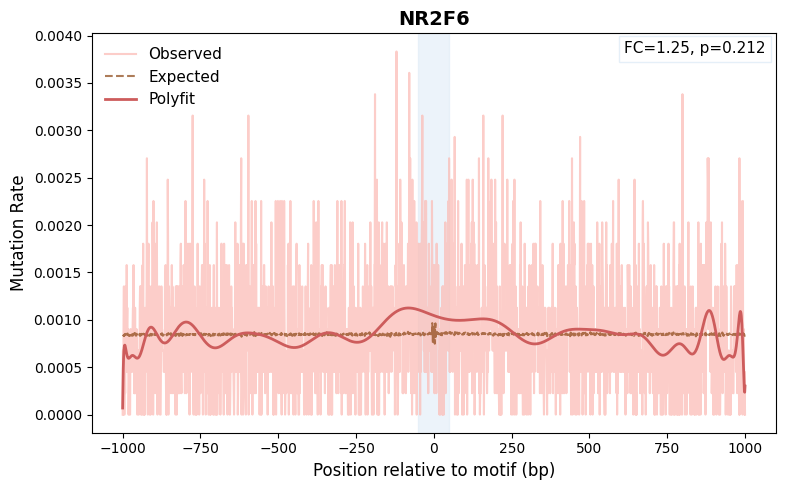

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: NRF1 Obs Sum: 16660 Exp Sum: 16660.00000000006
FC_core: 0.8959251437075908 OR_core0.8901347970053166 Pvalue_core: 0.01396757861609137 
FC_motif: 0.6175722898930104 OR_motif0.6171113413465659 Pvalue_motif: 0.00017910315257860173
FC motif:0.6175722898930104 Pvalue motif: 0.00017910315257860173
FC core:0.8959251437075908 Pvalue: 0.01396757861609137


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


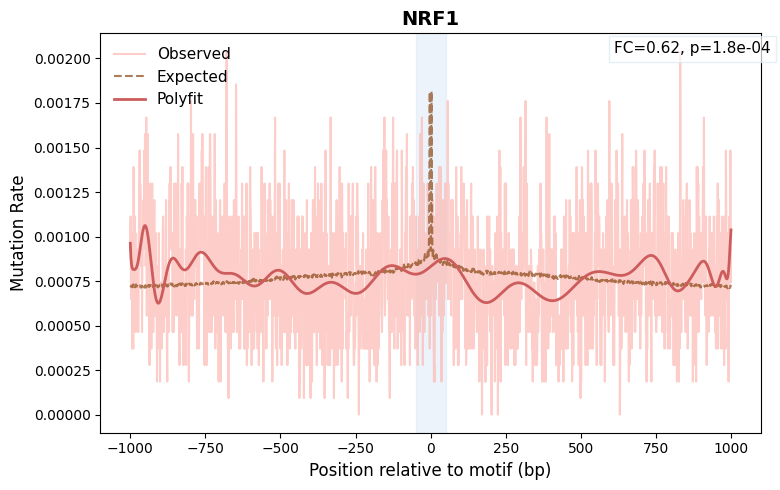

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: PBX2 Obs Sum: 4539 Exp Sum: 4539.000000000014
FC_core: 1.0767883816140194 OR_core1.0818573576350086 Pvalue_core: 0.4262085412066988 
FC_motif: 1.1620111741206034 OR_motif1.1862370468982406 Pvalue_motif: 0.6017340478378681
FC motif:1.1620111741206034 Pvalue motif: 0.6017340478378681
FC core:1.0767883816140194 Pvalue: 0.4262085412066988


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


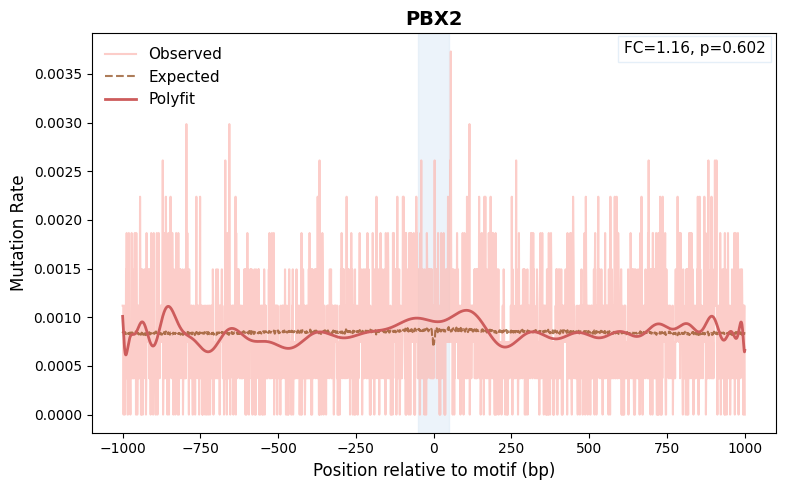

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: PPARG Obs Sum: 4347 Exp Sum: 4347.000000000014
FC_core: 1.2366177260290534 OR_core1.2556477764952512 Pvalue_core: 0.016019156249502092 
FC_motif: 1.1578332971006744 OR_motif1.17969776949749 Pvalue_motif: 0.4771926894529407
FC motif:1.1578332971006744 Pvalue motif: 0.4771926894529407
FC core:1.2366177260290534 Pvalue: 0.016019156249502092


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


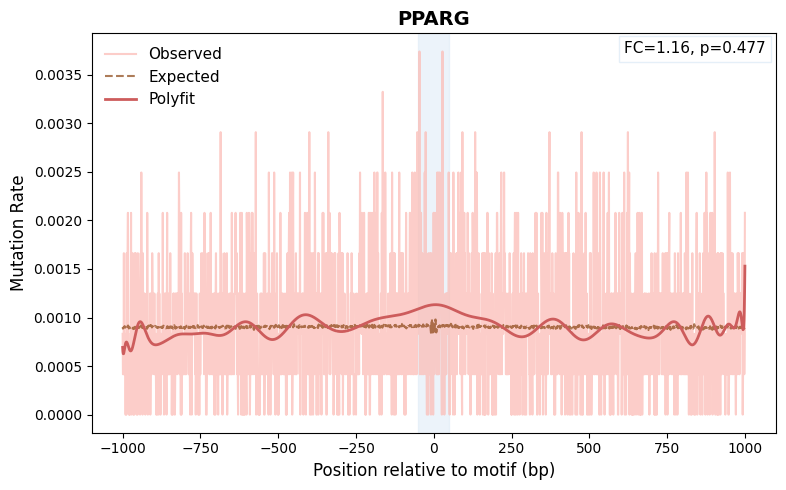

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: PROX1 Obs Sum: 1561 Exp Sum: 1561.0000000000045
FC_core: 1.1888956062939964 OR_core1.2012287195947986 Pvalue_core: 0.27339986440459474 
FC_motif: 1.3266510233326871 OR_motif1.4027149321266967 Pvalue_motif: 0.5396756928471007
FC motif:1.3266510233326871 Pvalue motif: 0.5396756928471007
FC core:1.1888956062939964 Pvalue: 0.27339986440459474


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


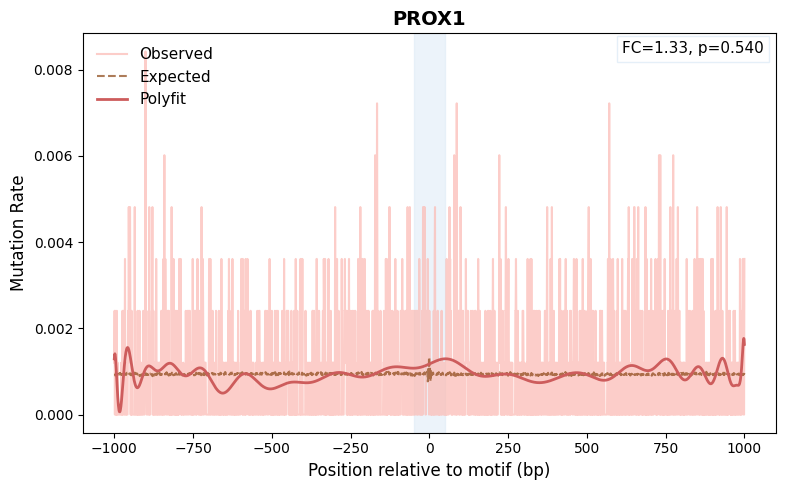

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: RARA Obs Sum: 13030 Exp Sum: 13030.00000000004
FC_core: 1.0754671401263252 OR_core1.0812951257900918 Pvalue_core: 0.16618598071405286 
FC_motif: 1.128873202616004 OR_motif1.1324636450105035 Pvalue_motif: 0.3498410823594059
FC motif:1.128873202616004 Pvalue motif: 0.3498410823594059
FC core:1.0754671401263252 Pvalue: 0.16618598071405286


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


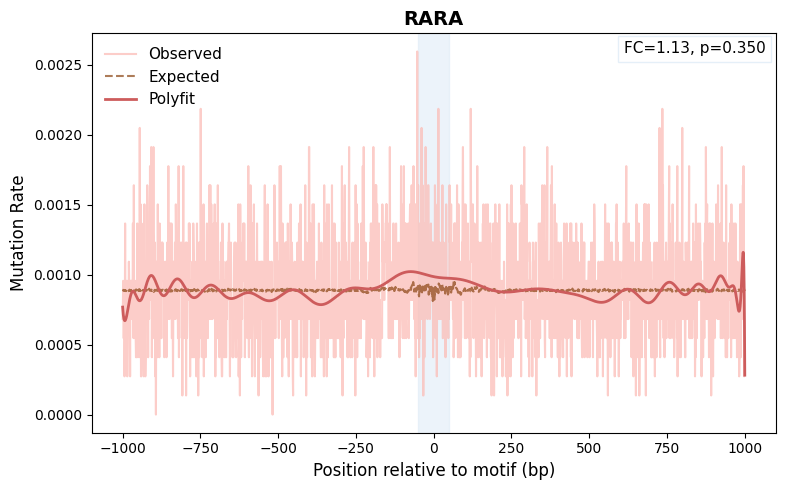

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: REST Obs Sum: 7721 Exp Sum: 7721.000000000023
FC_core: 1.0589185783170811 OR_core1.0627469986817686 Pvalue_core: 0.4123601807399785 
FC_motif: 1.0147608976006512 OR_motif1.0264500712726472 Pvalue_motif: 0.9354864339329408
FC motif:1.0147608976006512 Pvalue motif: 0.9354864339329408
FC core:1.0589185783170811 Pvalue: 0.4123601807399785


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


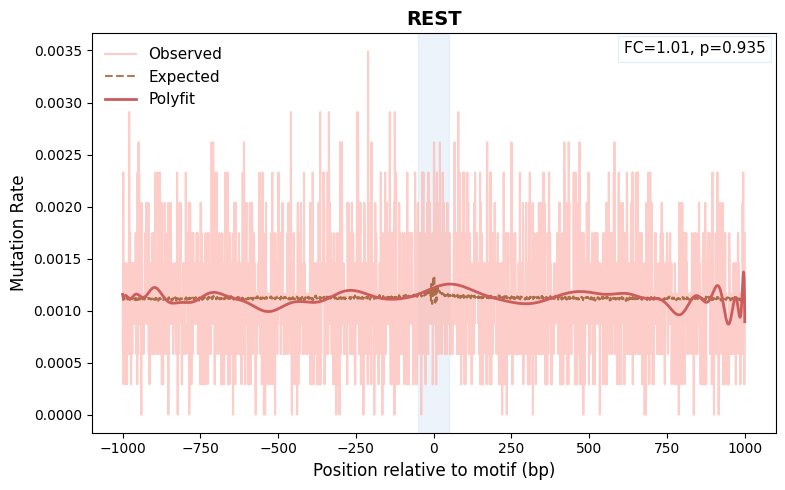

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: RFX3 Obs Sum: 8272 Exp Sum: 8272.000000000024
FC_core: 1.0406310645947918 OR_core1.0452929768225607 Pvalue_core: 0.5383053486644152 
FC_motif: 0.7561114732776549 OR_motif0.7582422398052343 Pvalue_motif: 0.11676046167657238
FC motif:0.7561114732776549 Pvalue motif: 0.11676046167657238
FC core:1.0406310645947918 Pvalue: 0.5383053486644152


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


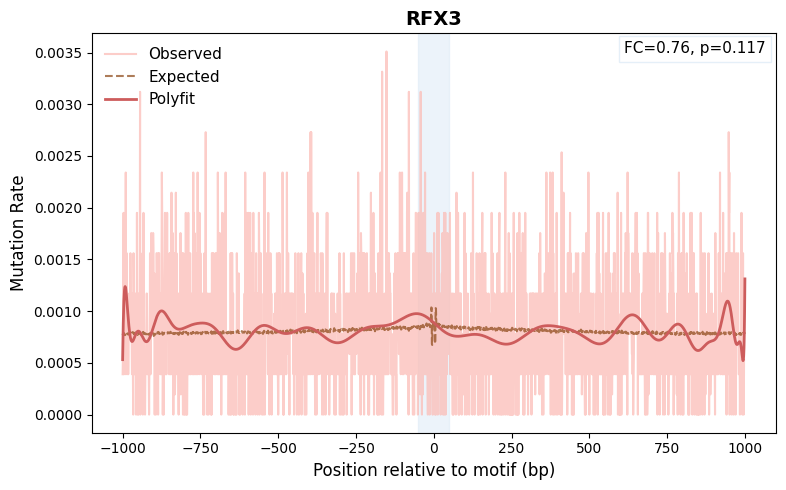

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: RFX5 Obs Sum: 2933 Exp Sum: 2933.0000000000086
FC_core: 1.0855892975768906 OR_core1.096633254410465 Pvalue_core: 0.45487278338982434 
FC_motif: 1.0267083060809337 OR_motif1.0454545454545454 Pvalue_motif: 1.0
FC motif:1.0267083060809337 Pvalue motif: 1.0
FC core:1.0855892975768906 Pvalue: 0.45487278338982434


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


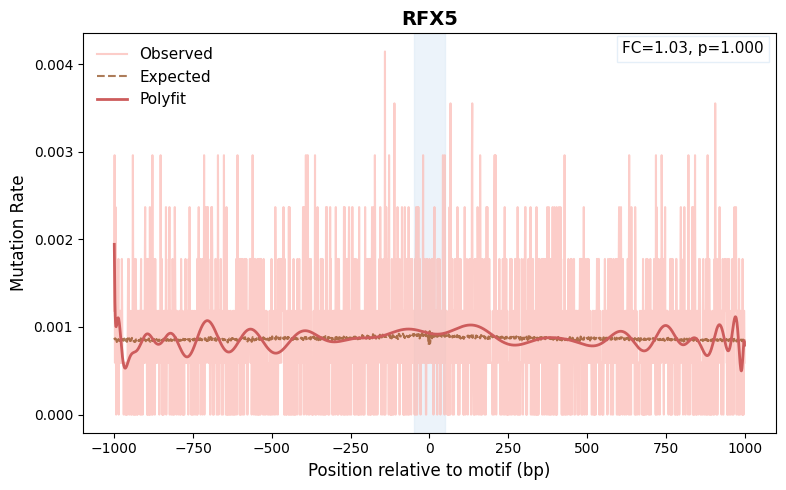

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: RREB1 Obs Sum: 3778 Exp Sum: 3778.000000000011
FC_core: 1.0503091510347533 OR_core1.0547311940715884 Pvalue_core: 0.641467093605216 
FC_motif: 0.6915072300290337 OR_motif0.6899083321370711 Pvalue_motif: 0.14030101761796993
FC motif:0.6915072300290337 Pvalue motif: 0.14030101761796993
FC core:1.0503091510347533 Pvalue: 0.641467093605216


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


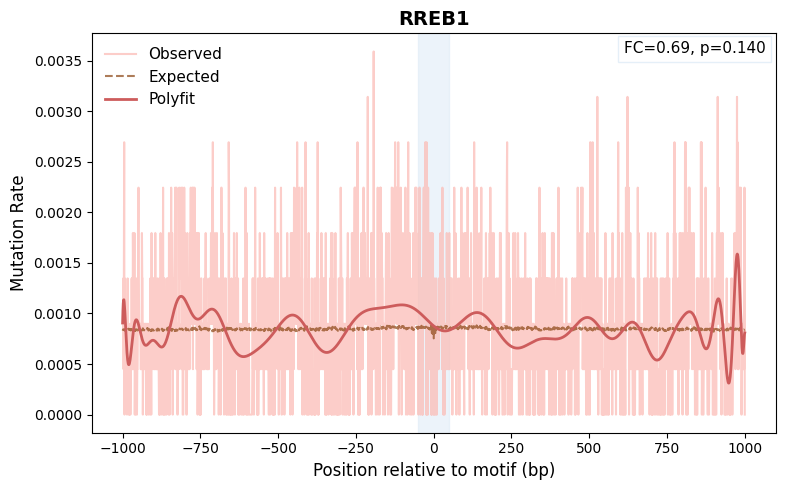

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: RXRB Obs Sum: 12200 Exp Sum: 12200.000000000033
FC_core: 1.2810550886724352 OR_core1.3019124827845248 Pvalue_core: 1.953856716738014e-06 
FC_motif: 1.1885855816333428 OR_motif1.19476023150062 Pvalue_motif: 0.24749712181435074
FC motif:1.1885855816333428 Pvalue motif: 0.24749712181435074
FC core:1.2810550886724352 Pvalue: 1.953856716738014e-06


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


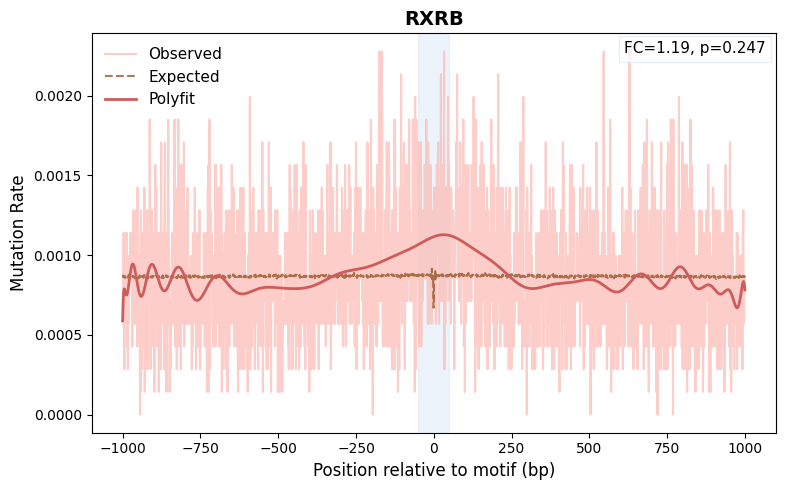

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: SOX13 Obs Sum: 2488 Exp Sum: 2488.0000000000073
FC_core: 1.1770733576366494 OR_core1.1966246847914457 Pvalue_core: 0.16922813155563438 
FC_motif: 1.4541733442272924 OR_motif1.5018174474959611 Pvalue_motif: 0.5025733429746291
FC motif:1.4541733442272924 Pvalue motif: 0.5025733429746291
FC core:1.1770733576366494 Pvalue: 0.16922813155563438


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


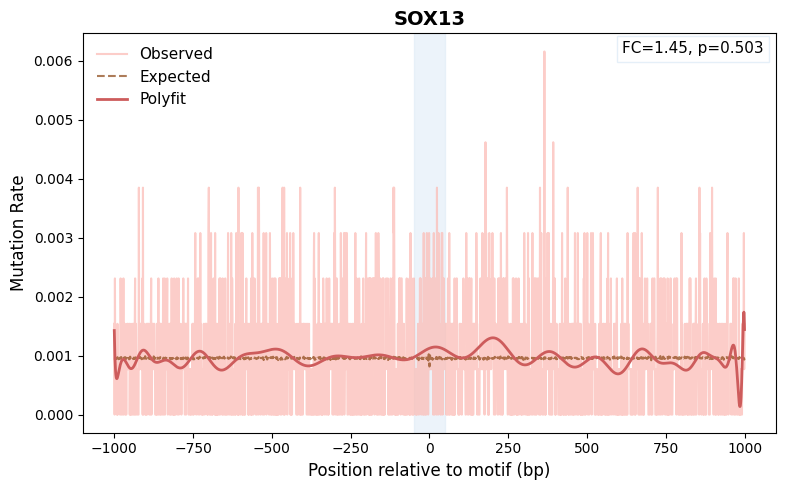

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: SOX13iso1 Obs Sum: 13112 Exp Sum: 13112.00000000004
FC_core: 1.1412524439689014 OR_core1.1512385965588654 Pvalue_core: 0.010923705872309182 
FC_motif: 1.4301223878976563 OR_motif1.443849238171612 Pvalue_motif: 0.07788838439121637
FC motif:1.4301223878976563 Pvalue motif: 0.07788838439121637
FC core:1.1412524439689014 Pvalue: 0.010923705872309182


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


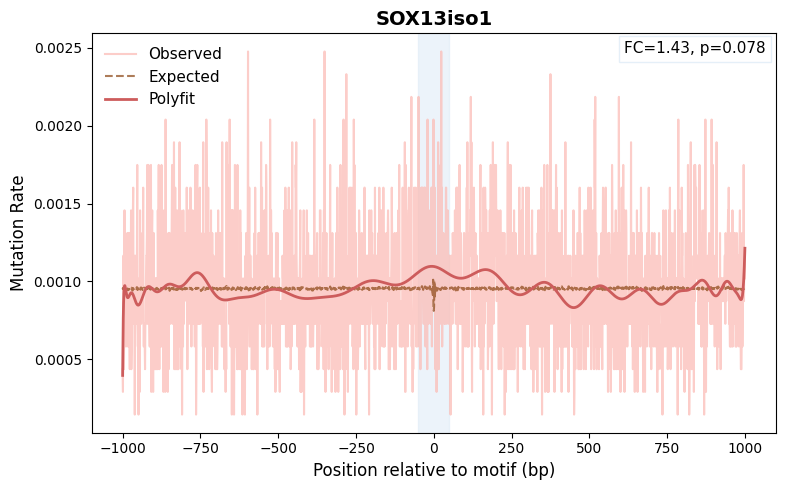

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: SP1 Obs Sum: 9767 Exp Sum: 9767.000000000031
FC_core: 0.8799530640689185 OR_core0.8747184563308728 Pvalue_core: 0.035809243482246275 
FC_motif: 0.4716322311399236 OR_motif0.475208583528222 Pvalue_motif: 0.0004747499704734938
FC motif:0.4716322311399236 Pvalue motif: 0.0004747499704734938
FC core:0.8799530640689185 Pvalue: 0.035809243482246275


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


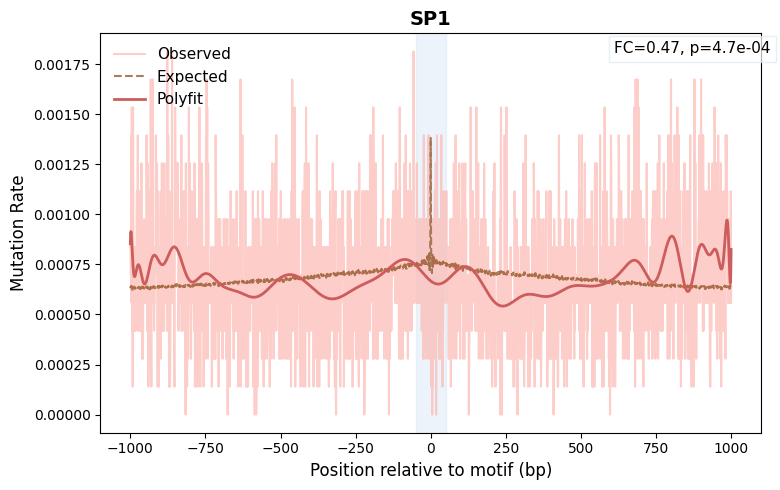

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: SP5 Obs Sum: 30177 Exp Sum: 30177.00000000007
FC_core: 0.9353624992526534 OR_core0.9323741428645886 Pvalue_core: 0.05649601127670348 
FC_motif: 1.0370404243920166 OR_motif1.04361712745783 Pvalue_motif: 0.7938191848518908
FC motif:1.0370404243920166 Pvalue motif: 0.7938191848518908
FC core:0.9353624992526534 Pvalue: 0.05649601127670348


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


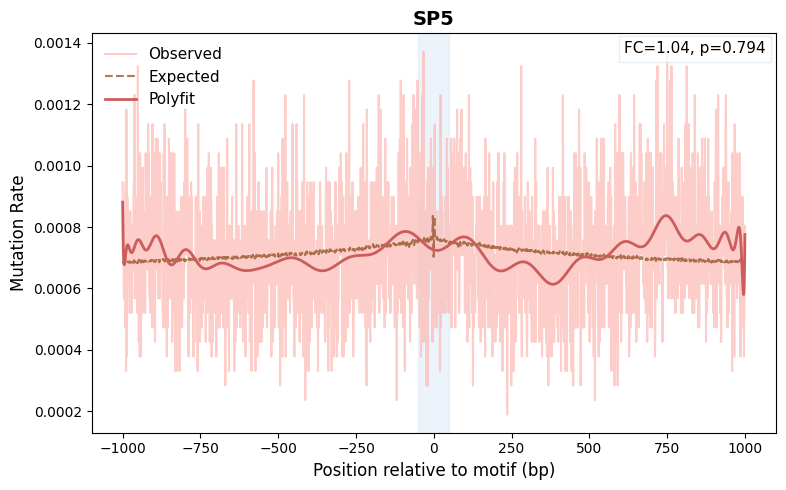

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: TBP Obs Sum: 2835 Exp Sum: 2835.000000000009
FC_core: 1.2007786125790316 OR_core1.2217040154703673 Pvalue_core: 0.08821989782039566 
FC_motif: 1.4612663273468116 OR_motif1.6273033309709426 Pvalue_motif: 0.382418625045652
FC motif:1.4612663273468116 Pvalue motif: 0.382418625045652
FC core:1.2007786125790316 Pvalue: 0.08821989782039566


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


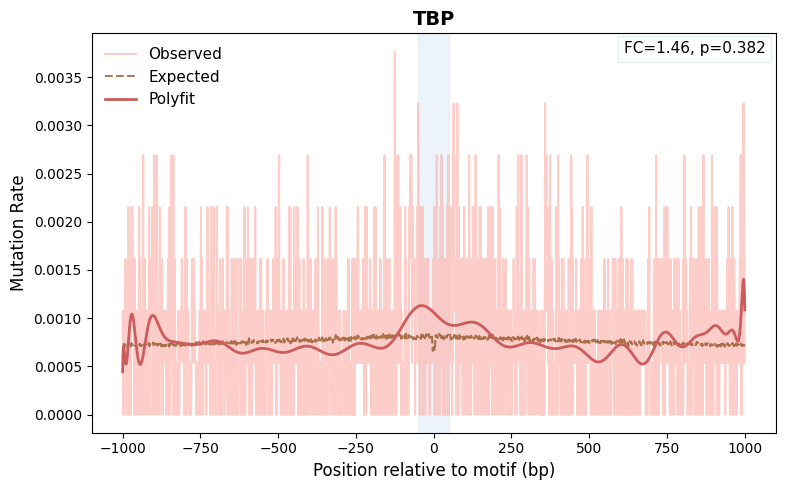

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: TCF7 Obs Sum: 9992 Exp Sum: 9992.000000000036
FC_core: 1.17176861860099 OR_core1.1825911120561343 Pvalue_core: 0.007966401802838198 
FC_motif: 1.057411771932996 OR_motif1.0614380158502033 Pvalue_motif: 0.8419862619734162
FC motif:1.057411771932996 Pvalue motif: 0.8419862619734162
FC core:1.17176861860099 Pvalue: 0.007966401802838198


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


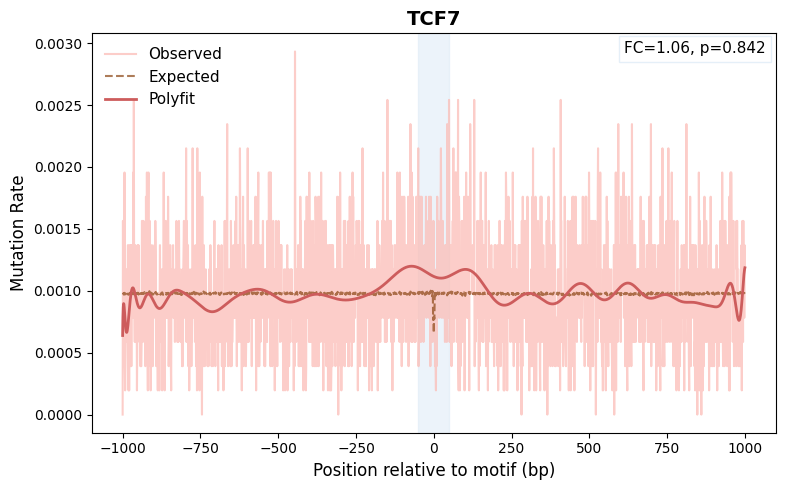

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: TEAD1 Obs Sum: 15072 Exp Sum: 15072.000000000044
FC_core: 1.1986217582981704 OR_core1.2120045647985598 Pvalue_core: 0.00014730754584959556 
FC_motif: 1.008003322767327 OR_motif1.0104166666666667 Pvalue_motif: 1.0
FC motif:1.008003322767327 Pvalue motif: 1.0
FC core:1.1986217582981704 Pvalue: 0.00014730754584959556


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


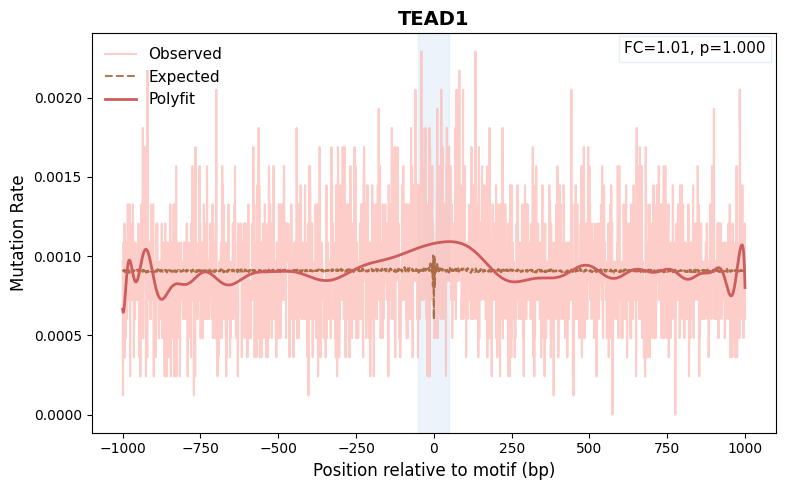

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: TEAD3 Obs Sum: 12818 Exp Sum: 12818.00000000004
FC_core: 1.1411552431705343 OR_core1.1513452926191843 Pvalue_core: 0.011337790375794443 
FC_motif: 1.0158896516423235 OR_motif1.0175438596491229 Pvalue_motif: 1.0
FC motif:1.0158896516423235 Pvalue motif: 1.0
FC core:1.1411552431705343 Pvalue: 0.011337790375794443


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


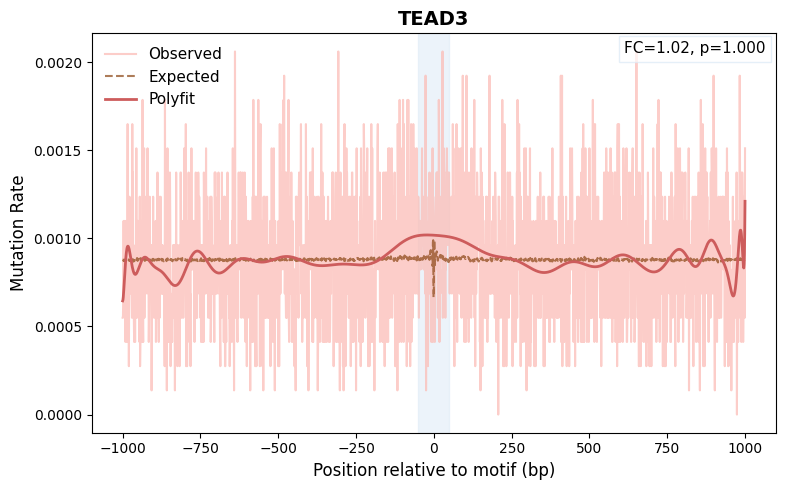

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: TFAP4 Obs Sum: 16513 Exp Sum: 16513.000000000047
FC_core: 1.2564187268111031 OR_core1.274012130843434 Pvalue_core: 3.6629645816585726e-07 
FC_motif: 0.8227645012242202 OR_motif0.8305669772253695 Pvalue_motif: 0.2565283283913003
FC motif:0.8227645012242202 Pvalue motif: 0.2565283283913003
FC core:1.2564187268111031 Pvalue: 3.6629645816585726e-07


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


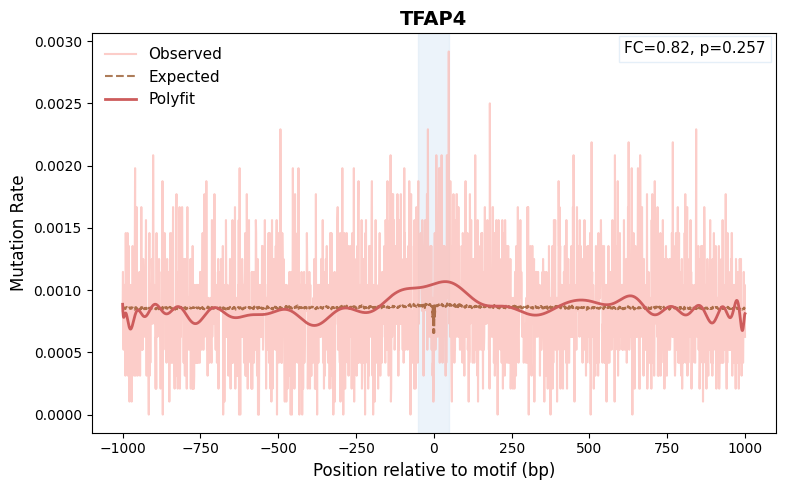

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: TFDP1 Obs Sum: 3011 Exp Sum: 3011.000000000011
FC_core: 0.9428509606923571 OR_core0.9443469101123596 Pvalue_core: 0.6134146982201709 
FC_motif: 1.2242044031749102 OR_motif1.239754327191513 Pvalue_motif: 0.5585164187406367
FC motif:1.2242044031749102 Pvalue motif: 0.5585164187406367
FC core:0.9428509606923571 Pvalue: 0.6134146982201709


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


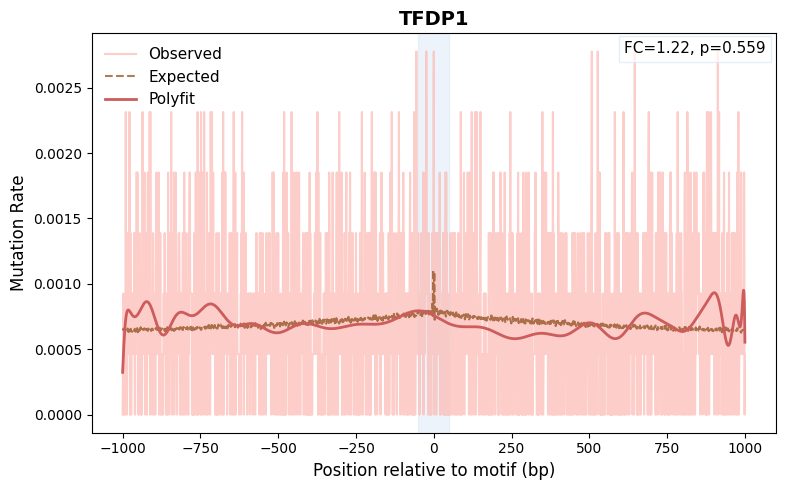

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: TFE3 Obs Sum: 8811 Exp Sum: 8811.000000000027
FC_core: 1.2288928130554733 OR_core1.247580156938672 Pvalue_core: 0.0005860295267707411 
FC_motif: 1.211769562403577 OR_motif1.2197142975962738 Pvalue_motif: 0.31762497175922466
FC motif:1.211769562403577 Pvalue motif: 0.31762497175922466
FC core:1.2288928130554733 Pvalue: 0.0005860295267707411


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


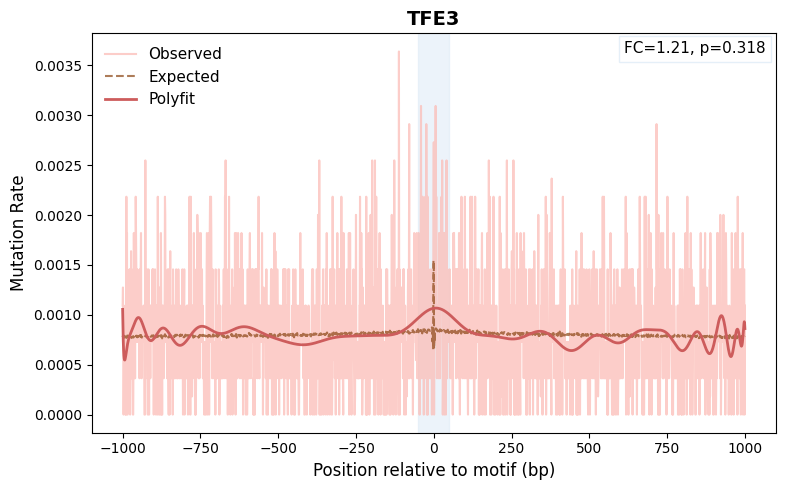

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: TGIF2 Obs Sum: 3277 Exp Sum: 3277.00000000001
FC_core: 1.2210051285493746 OR_core1.2409638554216869 Pvalue_core: 0.04867880710259731 
FC_motif: 1.5656508149698551 OR_motif1.6054237288135593 Pvalue_motif: 0.12484258964978495
FC motif:1.5656508149698551 Pvalue motif: 0.12484258964978495
FC core:1.2210051285493746 Pvalue: 0.04867880710259731


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


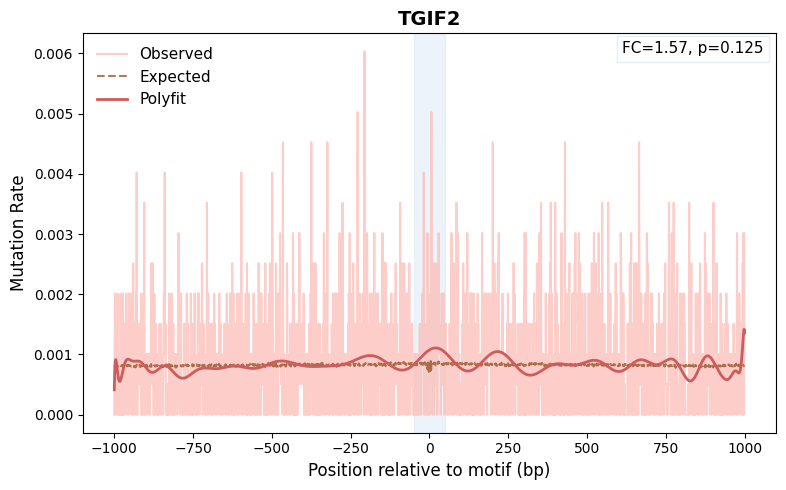

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: THAP11 Obs Sum: 13293 Exp Sum: 13293.00000000004
FC_core: 1.1630571539397687 OR_core1.1744520990272833 Pvalue_core: 0.002582444808101251 
FC_motif: 1.1486331332848947 OR_motif1.1535770020533882 Pvalue_motif: 0.2699641359650084
FC motif:1.1486331332848947 Pvalue motif: 0.2699641359650084
FC core:1.1630571539397687 Pvalue: 0.002582444808101251


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


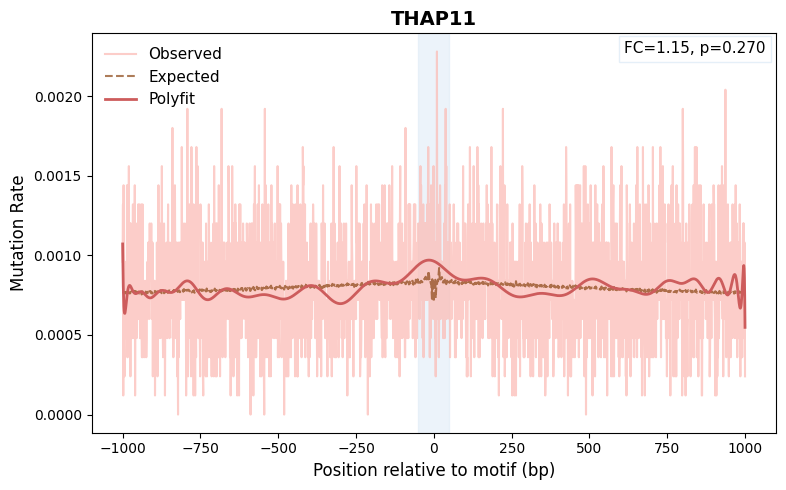

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: THRA Obs Sum: 6683 Exp Sum: 6683.000000000018
FC_core: 1.2522862089772866 OR_core1.272543072463768 Pvalue_core: 0.0012958087086212327 
FC_motif: 1.1333198369239466 OR_motif1.143082474410961 Pvalue_motif: 0.41172557316339264
FC motif:1.1333198369239466 Pvalue motif: 0.41172557316339264
FC core:1.2522862089772866 Pvalue: 0.0012958087086212327


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


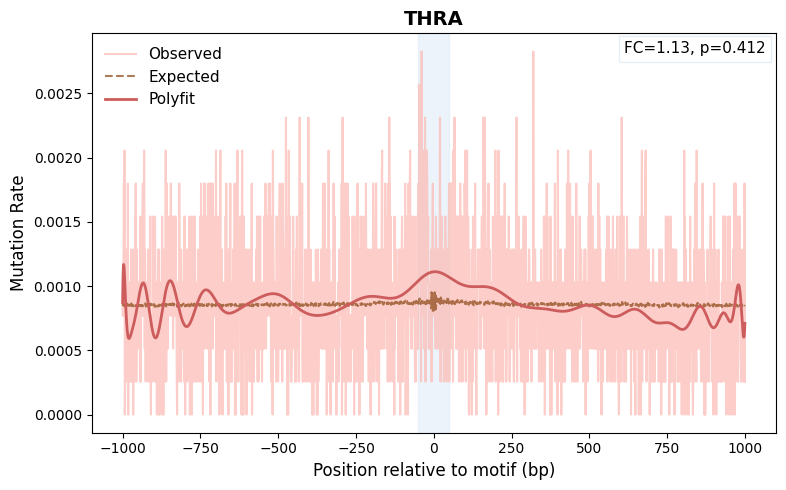

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: THRB Obs Sum: 4811 Exp Sum: 4811.000000000015
FC_core: 1.0872469637386937 OR_core1.0941041507335048 Pvalue_core: 0.34196395165271587 
FC_motif: 0.8575710886950488 OR_motif0.8682893933456663 Pvalue_motif: 0.5183886819358037
FC motif:0.8575710886950488 Pvalue motif: 0.5183886819358037
FC core:1.0872469637386937 Pvalue: 0.34196395165271587


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


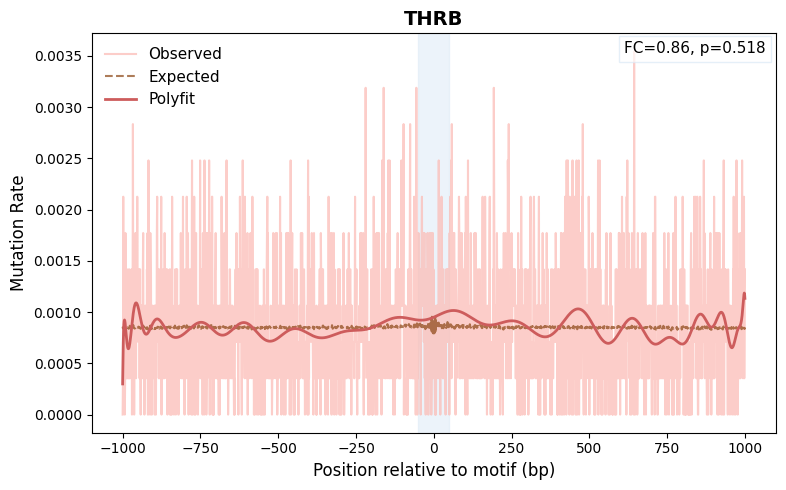

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: USF1 Obs Sum: 28991 Exp Sum: 28991.000000000095
FC_core: 1.0416720194526288 OR_core1.0447233247160295 Pvalue_core: 0.24394962268717812 
FC_motif: 0.8909626852829211 OR_motif0.8938239488187459 Pvalue_motif: 0.3027940182775101
FC motif:0.8909626852829211 Pvalue motif: 0.3027940182775101
FC core:1.0416720194526288 Pvalue: 0.24394962268717812


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


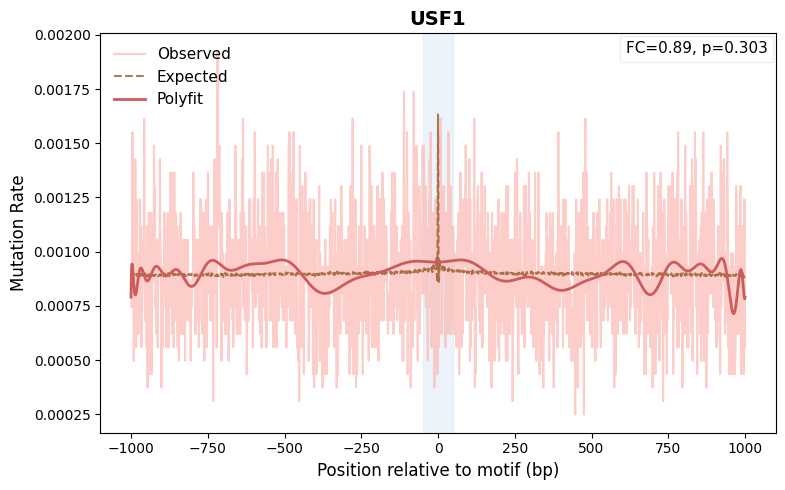

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: USF2 Obs Sum: 40865 Exp Sum: 40865.00000000011
FC_core: 1.0344460367630872 OR_core1.0365657530433707 Pvalue_core: 0.25532341171019746 
FC_motif: 0.9445764763902451 OR_motif0.9455015011743864 Pvalue_motif: 0.4435085787941645
FC motif:0.9445764763902451 Pvalue motif: 0.4435085787941645
FC core:1.0344460367630872 Pvalue: 0.25532341171019746


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


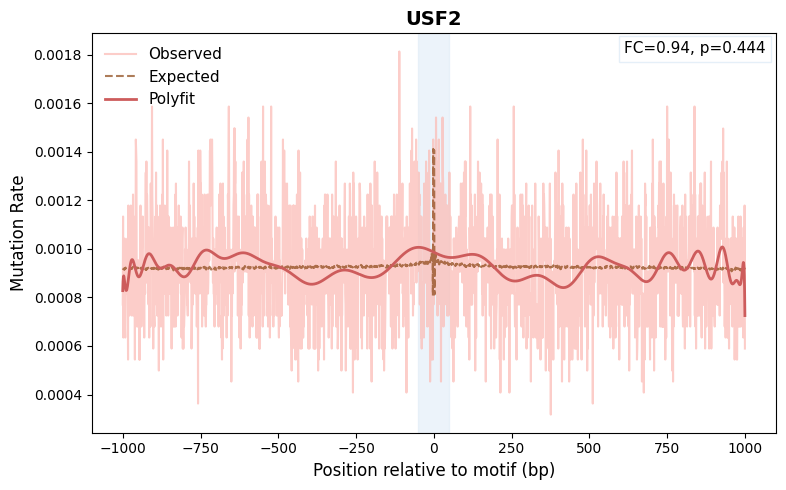

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: YY1 Obs Sum: 3893 Exp Sum: 3893.0000000000146
FC_core: 1.1178236967096933 OR_core1.1258468978238652 Pvalue_core: 0.23229139811741079 
FC_motif: 1.3826541518248905 OR_motif1.4689399810557133 Pvalue_motif: 0.3228507467246525
FC motif:1.3826541518248905 Pvalue motif: 0.3228507467246525
FC core:1.1178236967096933 Pvalue: 0.23229139811741079


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


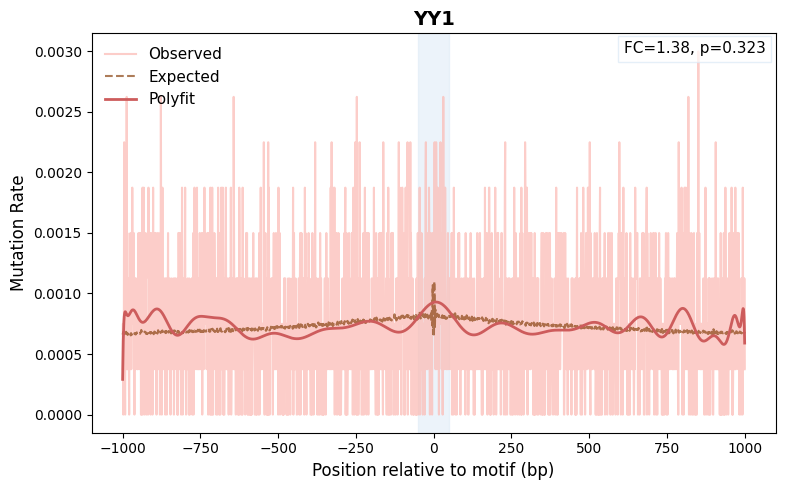

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: ZBTB21 Obs Sum: 3401 Exp Sum: 3401.0000000000105
FC_core: 1.167231867345273 OR_core1.1794808810284123 Pvalue_core: 0.12153424879704626 
FC_motif: 0.8221265324114061 OR_motif0.8489952718676123 Pvalue_motif: 0.6261290698696189
FC motif:0.8221265324114061 Pvalue motif: 0.6261290698696189
FC core:1.167231867345273 Pvalue: 0.12153424879704626


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


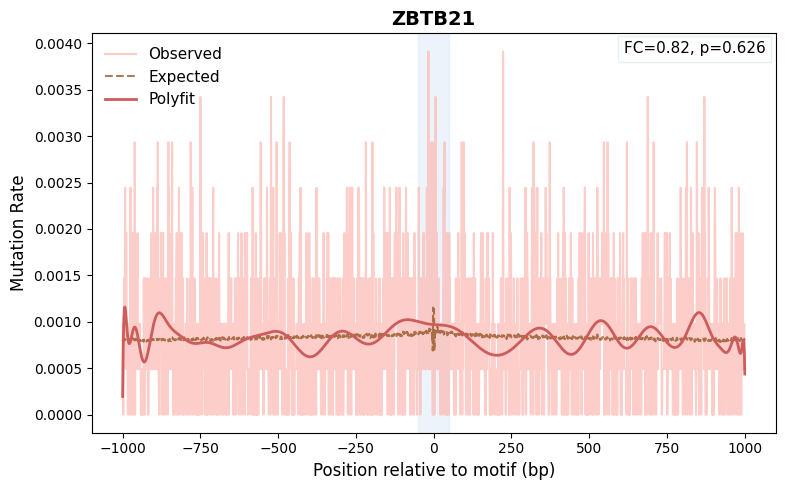

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: ZBTB26 Obs Sum: 5509 Exp Sum: 5509.000000000017
FC_core: 1.216790595212409 OR_core1.2312147924792363 Pvalue_core: 0.013273312018596894 
FC_motif: 1.2127437678037476 OR_motif1.2325722254306763 Pvalue_motif: 0.38930782836500216
FC motif:1.2127437678037476 Pvalue motif: 0.38930782836500216
FC core:1.216790595212409 Pvalue: 0.013273312018596894


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


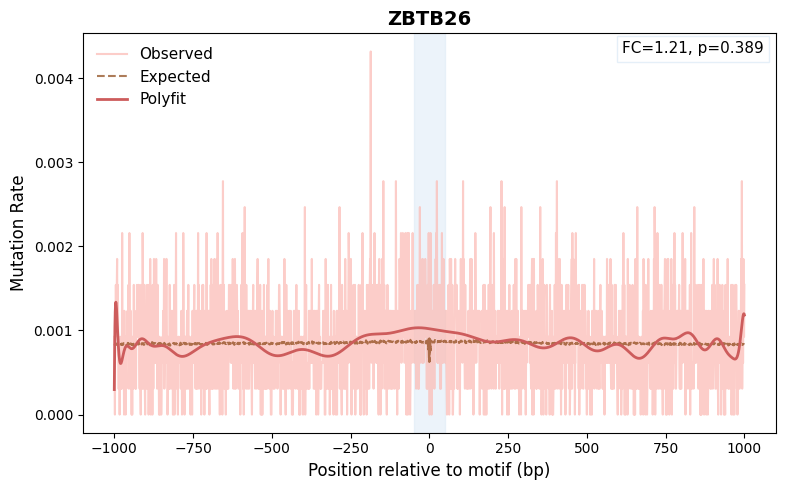

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: ZBTB7A Obs Sum: 1196 Exp Sum: 1196.000000000004
FC_core: 1.1012855079027908 OR_core1.1119701017296744 Pvalue_core: 0.6001590420225937 
FC_motif: 0.7996452248427806 OR_motif0.8735281749369218 Pvalue_motif: 0.8029594186740195
FC motif:0.7996452248427806 Pvalue motif: 0.8029594186740195
FC core:1.1012855079027908 Pvalue: 0.6001590420225937


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


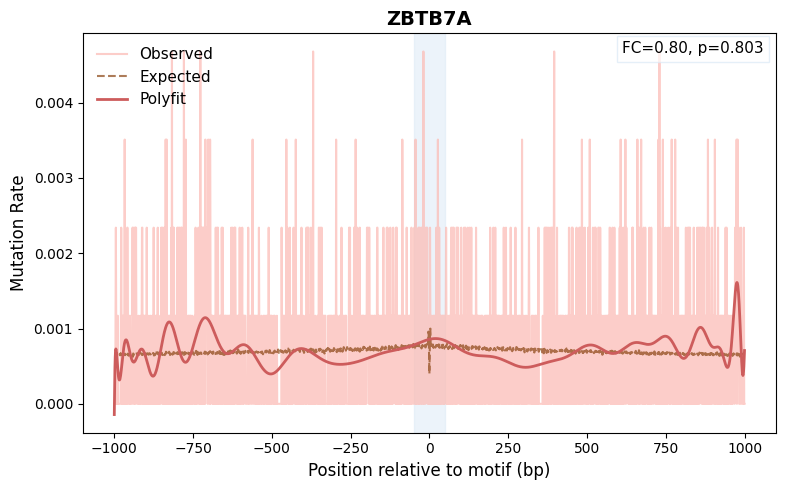

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: ZFP1 Obs Sum: 2282 Exp Sum: 2282.0000000000073
FC_core: 1.2974834292947648 OR_core1.3278513912535677 Pvalue_core: 0.03062456740774412 
FC_motif: 1.316970057707445 OR_motif1.3559357341874332 Pvalue_motif: 0.4275465237926059
FC motif:1.316970057707445 Pvalue motif: 0.4275465237926059
FC core:1.2974834292947648 Pvalue: 0.03062456740774412


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


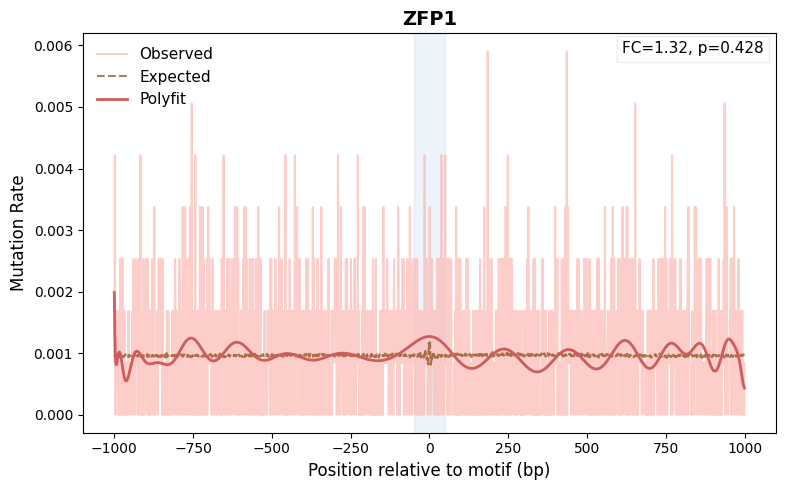

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: ZFP64 Obs Sum: 2430 Exp Sum: 2430.000000000007
FC_core: 1.074557664133529 OR_core1.0829742008371936 Pvalue_core: 0.5690245543254191 
FC_motif: 1.257377430730571 OR_motif1.3093181166119416 Pvalue_motif: 0.5834894434156496
FC motif:1.257377430730571 Pvalue motif: 0.5834894434156496
FC core:1.074557664133529 Pvalue: 0.5690245543254191


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


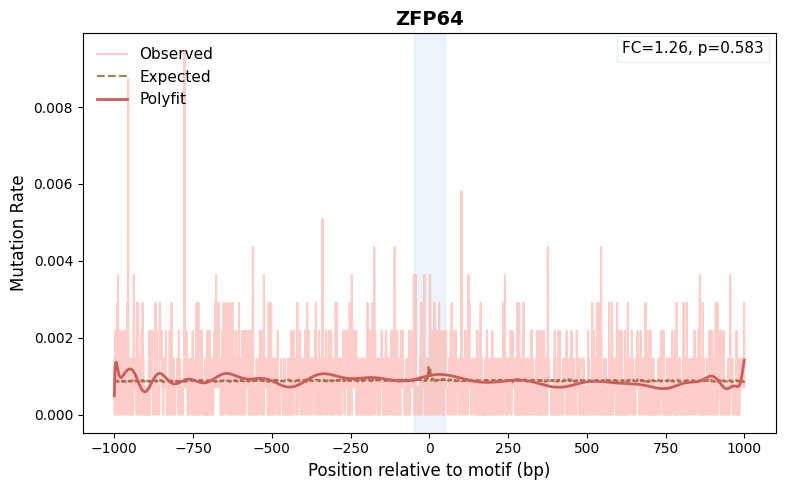

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: ZKSCAN8 Obs Sum: 3889 Exp Sum: 3889.000000000009
FC_core: 1.317705214806305 OR_core1.3456687074974047 Pvalue_core: 0.0026498082236998156 
FC_motif: 1.2121301130693118 OR_motif1.2301528979495082 Pvalue_motif: 0.3603045351979238
FC motif:1.2121301130693118 Pvalue motif: 0.3603045351979238
FC core:1.317705214806305 Pvalue: 0.0026498082236998156


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


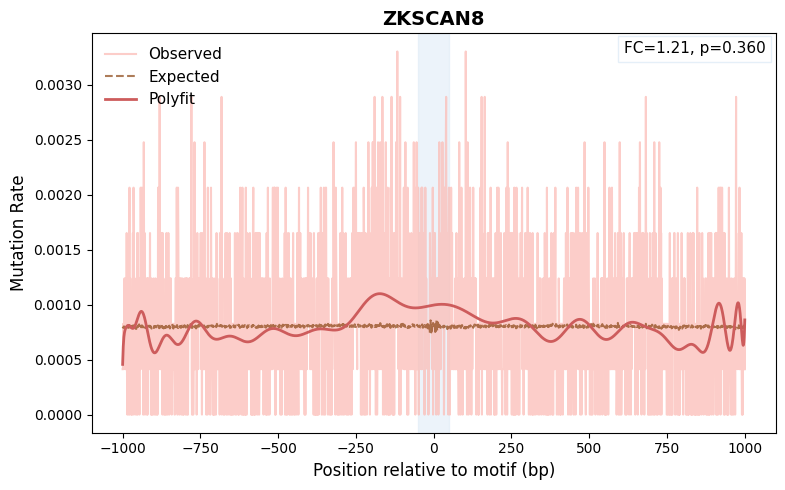

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: ZNF12 Obs Sum: 4808 Exp Sum: 4808.000000000015
FC_core: 1.0185823342075333 OR_core1.0216418874301691 Pvalue_core: 0.8524436515899803 
FC_motif: 0.9845353255306245 OR_motif0.9997898718218113 Pvalue_motif: 1.0
FC motif:0.9845353255306245 Pvalue motif: 1.0
FC core:1.0185823342075333 Pvalue: 0.8524436515899803


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


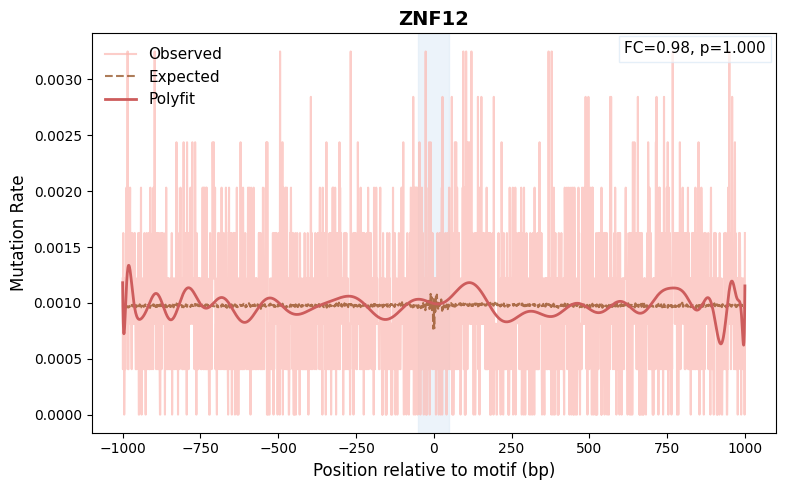

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: ZNF143 Obs Sum: 4560 Exp Sum: 4560.000000000015
FC_core: 1.0088889328321113 OR_core1.0128150094152257 Pvalue_core: 0.9259386765007107 
FC_motif: 0.8086161324196406 OR_motif0.8190631512186283 Pvalue_motif: 0.4077166053874971
FC motif:0.8086161324196406 Pvalue motif: 0.4077166053874971
FC core:1.0088889328321113 Pvalue: 0.9259386765007107


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


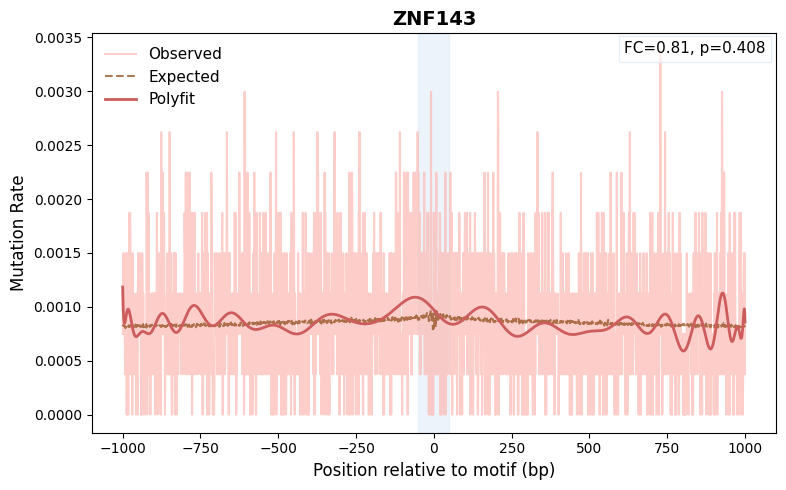

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: ZNF281 Obs Sum: 16678 Exp Sum: 16678.000000000044
FC_core: 0.8667019933772251 OR_core0.8606168423157113 Pvalue_core: 0.0030714217793556377 
FC_motif: 0.7885040732180294 OR_motif0.7921444242537213 Pvalue_motif: 0.08913371934021241
FC motif:0.7885040732180294 Pvalue motif: 0.08913371934021241
FC core:0.8667019933772251 Pvalue: 0.0030714217793556377


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


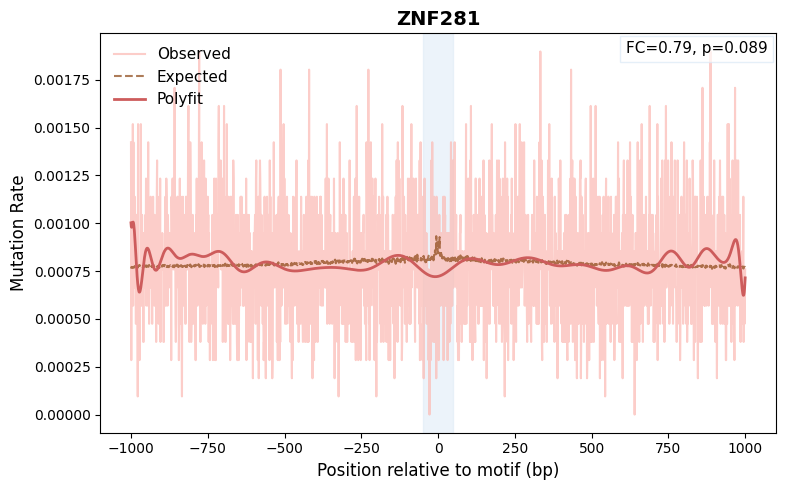

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: ZNF331 Obs Sum: 10905 Exp Sum: 10905.000000000031
FC_core: 1.1418520600104693 OR_core1.1525341130604287 Pvalue_core: 0.017884015720190757 
FC_motif: 1.0571377038846828 OR_motif1.0606330285550076 Pvalue_motif: 0.7588744198995567
FC motif:1.0571377038846828 Pvalue motif: 0.7588744198995567
FC core:1.1418520600104693 Pvalue: 0.017884015720190757


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


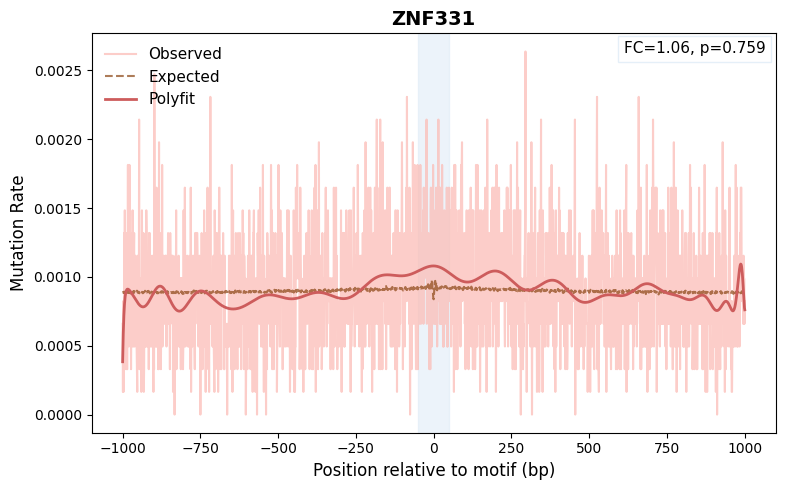

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: ZNF384 Obs Sum: 166128 Exp Sum: 166128.00000000052
FC_core: 1.04668643389303 OR_core1.0491730582190681 Pvalue_core: 0.0034651043916892827 
FC_motif: 1.1367552056561228 OR_motif1.1382268766112071 Pvalue_motif: 0.017032213033317756
FC motif:1.1367552056561228 Pvalue motif: 0.017032213033317756
FC core:1.04668643389303 Pvalue: 0.0034651043916892827


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


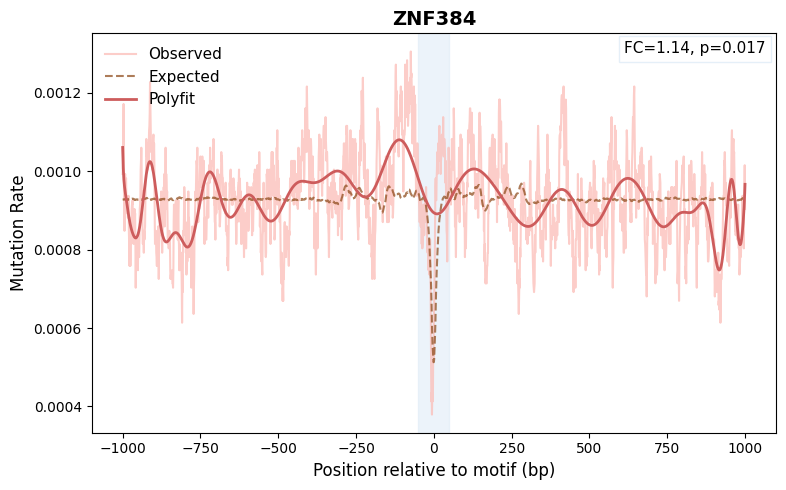

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: ZNF544 Obs Sum: 3378 Exp Sum: 3378.00000000001
FC_core: 1.1987639884468602 OR_core1.212878787878788 Pvalue_core: 0.07423853146643065 
FC_motif: 0.6575451675525995 OR_motif0.6640826873385013 Pvalue_motif: 0.12203502948144565
FC motif:0.6575451675525995 Pvalue motif: 0.12203502948144565
FC core:1.1987639884468602 Pvalue: 0.07423853146643065


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


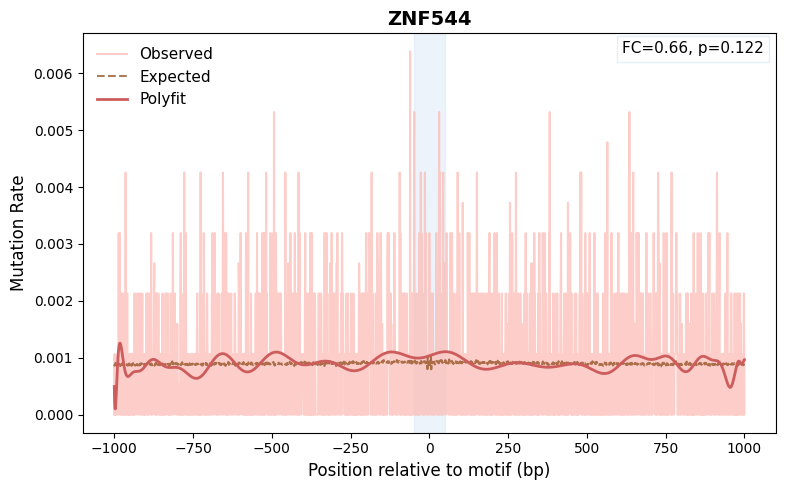

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: ZNF580 Obs Sum: 5481 Exp Sum: 5481.000000000016
FC_core: 0.9153346783040832 OR_core0.9128442490164314 Pvalue_core: 0.29658315705541904 
FC_motif: 0.9727695321970021 OR_motif0.9814563545906829 Pvalue_motif: 0.9237136905073238
FC motif:0.9727695321970021 Pvalue motif: 0.9237136905073238
FC core:0.9153346783040832 Pvalue: 0.29658315705541904


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


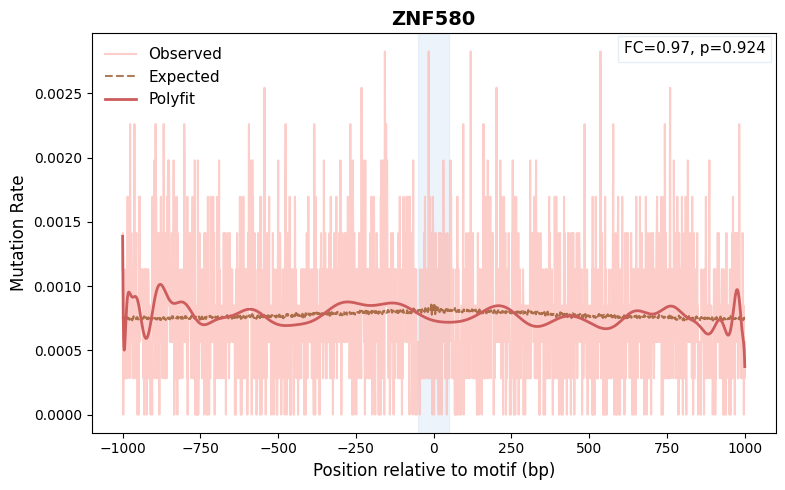

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: ZNF652 Obs Sum: 9180 Exp Sum: 9180.000000000025
FC_core: 1.0208515761549712 OR_core1.0228421781090145 Pvalue_core: 0.761753374280447 
FC_motif: 0.7867483743590873 OR_motif0.7989492119089316 Pvalue_motif: 0.269942944365336
FC motif:0.7867483743590873 Pvalue motif: 0.269942944365336
FC core:1.0208515761549712 Pvalue: 0.761753374280447


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


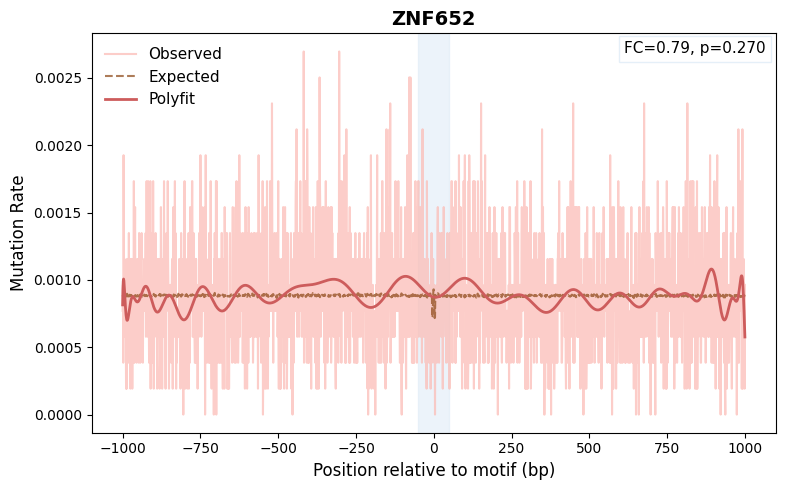

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: ZNF7 Obs Sum: 2648 Exp Sum: 2648.000000000009
FC_core: 0.9208946328818421 OR_core0.9202176155857866 Pvalue_core: 0.5210323931249584 
FC_motif: 1.0151100005780525 OR_motif1.1428571428571428 Pvalue_motif: 1.0
FC motif:1.0151100005780525 Pvalue motif: 1.0
FC core:0.9208946328818421 Pvalue: 0.5210323931249584


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


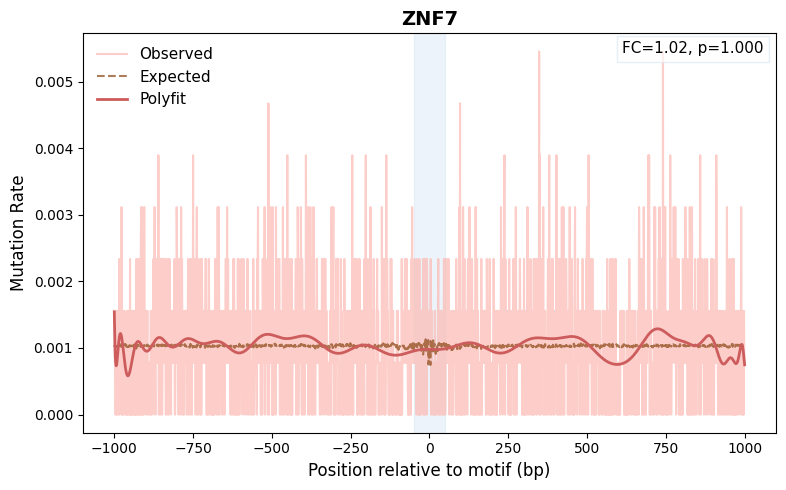

/tmp/ipykernel_4027951/2168853910.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  motif = math.floor((df2[3].unique())/2)


Samples: PCAWG_all_samples Gene: ZSCAN9 Obs Sum: 2506 Exp Sum: 2506.0000000000077
FC_core: 1.1276541917254943 OR_core1.1426052435362635 Pvalue_core: 0.31594786636573935 
FC_motif: 1.2782359911900683 OR_motif1.283104284559418 Pvalue_motif: 0.4243856774199433
FC motif:1.2782359911900683 Pvalue motif: 0.4243856774199433
FC core:1.1276541917254943 Pvalue: 0.31594786636573935


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


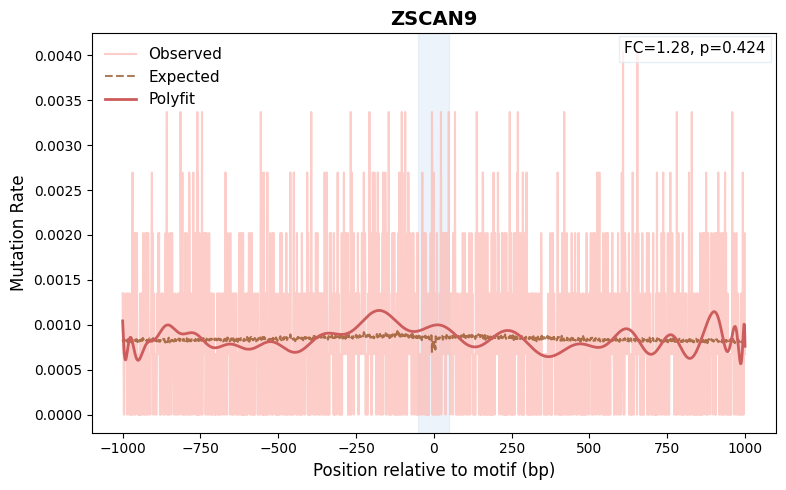

Duration: 1:24:14.677853


In [26]:
from datetime import datetime
start_time = datetime.now()


core = 50
dhs = 250
flank_size = 1000

for tumor_type in ['PCAWG_all_samples']:
    
    # read signature probabilities
    sign_dict = mut_prob.set_index('mutation').T.to_dict()
    
    
    HCCnbp_bed = pbt.BedTool.from_dataframe(HCC_nbp)
    
    #creating a list for the plot_values later on
    plot_values = []
    pos_muts = pd.DataFrame()
    p_value = []
    
    for gene in wMotif[4].unique().tolist():
        #to get a list of all the (unique)genes presnt in the dataframe
        #adding the unique gene list to a df
        df2=wMotif[wMotif[4]== gene]
        #df2_len = (len(df2)) 
        
        df2_bed = pbt.BedTool.from_dataframe(df2)
        #saving the value of length of the motif
        motif = math.floor((df2[3].unique())/2)
        pfm = df2[5].iloc[0]
    
        # intersect mutations with the TFBS region
        res1 = df2_bed.intersect(HCCnbp_bed, wo=True)
        res_df = res1.to_dataframe(header=None)
        res_df.columns = range(res_df.shape[1])
        res = pbt.BedTool.from_dataframe(res_df)
        #print(res_df)
                              
        obs_counts = defaultdict(int)
        for row in res:
            middle = int(row[2])-flank_size
            diff = int(row[8])-middle
            obs_counts[diff] += 1
    
        collect = []
        for i in range(-flank_size, flank_size+1, 1):
            if i in obs_counts.keys():
                collect.append([i, obs_counts[i]])
            else:
                collect.append([i, 0])

        obs_df = pd.DataFrame(collect, columns=['position', 'observed_muts'])
        obs_norm = obs_df.copy()
        obs_norm['observed_muts'] = obs_norm['observed_muts']/len(df2) 

#       get expected mutation count
        final_position_prob_df = get_exp_mut(res_df, flank_size, sign_dict, gene, "Probability_%s" % tumor_type)
        
        final_position_prob_norm = final_position_prob_df.copy()
        final_position_prob_norm['expected_muts'] = final_position_prob_df['expected_muts']/len(df2)
    
        print(
            f"Samples: {tumor_type}",
            f"Gene: {gene}",
            f"Obs Sum: {obs_df['observed_muts'].sum()}",
            f"Exp Sum: {final_position_prob_df['expected_muts'].sum()}"
        )
            
        to_plot = pd.merge(obs_df, final_position_prob_df, on='position')
        to_plot["TFBS"] = gene
        to_plot_normalised = pd.merge(obs_norm, final_position_prob_norm, on='position')
        to_plot_normalised["TFBS"] = gene
        
        # Append the modified DataFrame to the list
        plot_values.append(to_plot)

        # Concatenate all the DataFrames in the list into one DataFrame
        pos_muts = pd.concat(plot_values, ignore_index=True)
        
    
        # Fishers-test to find out if the number of mutations at the core is more than expected
        obs_motif, obs_muts, obs_motif_flank, obs_flank_muts, exp_motif, exp_muts, exp_motif_flank, exp_flank_muts, fc_motif, fc_core, fc_dhs, fc_flanks, odd_ratio_motif, p_value_motif, odd_ratio_core, p_value_core = fisherstest(to_plot, motif, core, dhs, flank_size)
        # adding all observed and expected values to a df
        p_value.append([gene, obs_motif, obs_muts, obs_motif_flank, 
                        obs_flank_muts, exp_motif, exp_muts, exp_motif_flank, 
                        exp_flank_muts, fc_motif, fc_core, fc_dhs, fc_flanks, 
                        odd_ratio_motif, p_value_motif, odd_ratio_core, p_value_core])
        p_value_df = pd.DataFrame(p_value)
        p_value_df.columns = ["Gene", "Obs_motif", "Obs_core101", "Obs_motif_flank", "Obs_flank", 
                              "Exp_motif", "Exp_core101", "Exp_motif_flank", "Exp_flank", 
                              "FC_motif", "FC_50", "FC_dhs(250)", "FC_flank", 
                              "OddsRatio_motif", "P-value_motif", "OddsRatio_core", "P-value50"]    
        print(f"FC motif:{fc_motif}", f"Pvalue motif: {p_value_motif}")
        print(f"FC core:{fc_core}", f"Pvalue: {p_value_core}")
        
        #Plots
        fig, ax = plt.subplots(figsize=(8,5))
        # Observed (light pink)
        plt.plot(to_plot_normalised['position'], to_plot_normalised['observed_muts'], color="#fcb9b2", alpha=0.7, label="Observed")
        # Expected (saddle brown dashed)
        plt.plot(to_plot_normalised['position'], to_plot_normalised['expected_muts'], color="saddlebrown", linestyle="--", label="Expected", alpha = 0.7)
        # Highlight core region
        ax.axvspan(-core, core, color="#dbe9f6", alpha=0.5)

        # Asthetics
        plt.title("%s %s" % (tumor_type, gene))
        #plt.text(0.8, 0.93,'fc='+ str(fc_core)[:4]+' ,P='+"%.3f"%(p_value_core), ha='center', va='center', bbox={'facecolor':'w','pad':5}, transform=plt.gca().transAxes)
        coefs = poly.polyfit(to_plot_normalised['position'], to_plot_normalised['observed_muts'], 50)
        ffit = poly.polyval (to_plot_normalised['position'], coefs)
        plt.plot(to_plot_normalised['position'], ffit,color="indianred", linewidth= 2, zorder=3, label="Polyfit")
        
        # Title + annotation
        ax.set_title(f"{gene}", fontsize=14, weight="bold")
        ax.set_xlabel("Position relative to motif (bp)", fontsize=12)
        ax.set_ylabel("Mutation Rate", fontsize=12)
        label_text = format_fc_p(fc_motif, p_value_motif, tiny_thresh=1e-4)
        ax.text(
            0.778, 0.98, label_text,
            transform=ax.transAxes, ha="left", va="top",
            fontsize=11, bbox=dict(facecolor="white", alpha=0.7, edgecolor="#dbe9f6")
        )
        ax.legend(loc="upper left", frameon=False, fontsize=11)
        plt.tight_layout()
        plt.show()

      
       # break
        
end_time = datetime.now()
print('Duration: {}'.format(end_time - start_time))

In [27]:
p_value_df

,Gene,Obs_motif,Obs_core101,Obs_motif_flank,Obs_flank,Exp_motif,Exp_core101,Exp_motif_flank,Exp_flank,FC_motif,FC_50,FC_dhs(250),FC_flank,OddsRatio_motif,P-value_motif,OddsRatio_core,P-value50
0,BACH1,69,611,12599,12057,80.841880,638.128193,12587.158120,12029.871807,0.853518,0.957488,1.000443,1.002783,0.861679,3.677378e-01,0.955456,4.334963e-01
1,BHLHE40,62,633,11331,10760,79.611209,615.969899,11313.388791,10777.030101,0.778785,1.027648,1.007944,0.994802,0.783563,1.521607e-01,1.030894,6.206418e-01
2,CEBPA,304,2359,36863,34808,197.606855,1876.387347,36969.393145,35290.612653,1.538408,1.257203,1.053688,0.968610,1.547585,1.852563e-06,1.274875,2.262660e-14
3,CEBPB,506,2985,46115,43636,259.602168,2358.936324,46361.397832,44262.063676,1.949136,1.265401,1.020123,0.976780,1.964090,2.075712e-19,1.284064,1.046882e-18
4,CEBPD,31,332,3906,3605,22.754444,206.802501,3914.245556,3730.197499,1.362371,1.605396,1.079562,0.935773,1.411977,2.700570e-01,1.667533,2.066217e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,ZNF544,24,210,3354,3168,36.499394,175.180438,3341.500606,3202.819562,0.657545,1.198764,1.004863,0.987493,0.664083,1.220350e-01,1.212879,7.423853e-02
86,ZNF580,54,266,5427,5215,55.511607,290.604089,5425.488393,5190.395911,0.972770,0.915335,1.011207,1.003434,0.981456,9.237137e-01,0.912844,2.965832e-01
87,ZNF652,44,469,9136,8711,55.926395,459.420361,9124.073605,8720.579639,0.786748,1.020852,1.034632,0.989601,0.798949,2.699429e-01,1.022842,7.617534e-01
88,ZNF7,8,122,2640,2526,7.880919,132.479869,2640.119081,2515.520131,1.015110,0.920895,0.990463,1.007963,1.142857,1.000000e+00,0.920218,5.210324e-01


"->"

In [28]:
#p_value_df.to_csv(OUTPUT_DIR / "PCAWG_90TF_motif_mutation_rate_statistics.csv",sep="\t",index=False)
pos_muts.to_csv(OUTPUT_DIR / "PCAWG_90TF_motif_position_mutation_profiles.csv",sep="\t",index=False)

In [9]:
pbt.cleanup()

#### FDR corrections

##### Motif

In [13]:
# BH-FDR correction for motif enrichment
fdr_motif = statsmodels.stats.multitest.multipletests(p_value_df["P-value_motif"],method="fdr_bh",
    is_sorted=False,returnsorted=False)
p_value_df["fdr_motif"] = fdr_motif[1]

p_value_df["fdrmotif_log10"] = -np.log10(p_value_df["fdr_motif"])
p_value_df["log2Fc_motif"] = np.log2(p_value_df["FC_motif"])
p_value_df["log2OR_motif"] = np.log2(p_value_df["OddsRatio_motif"])

p_value_df.head()

,Gene,Obs_motif,Obs_core101,Obs_motif_flank,Obs_flank,Exp_motif,Exp_core101,Exp_motif_flank,Exp_flank,FC_motif,...,FC_dhs(250),FC_flank,OddsRatio_motif,P-value_motif,OddsRatio_core,P-value50,fdr_motif,fdrmotif_log10,log2Fc_motif,log2OR_motif
0,BACH1,69,611,12599,12057,80.841880,638.128193,12587.158120,12029.871807,0.853518,...,1.000443,1.002783,0.861679,3.677378e-01,0.955456,4.334963e-01,7.194869e-01,0.142977,-0.228507,-0.214778
1,BHLHE40,62,633,11331,10760,79.611209,615.969899,11313.388791,10777.030101,0.778785,...,1.007944,0.994802,0.783563,1.521607e-01,1.030894,6.206418e-01,5.267100e-01,0.278428,-0.360703,-0.351878
2,CEBPA,304,2359,36863,34808,197.606855,1876.387347,36969.393145,35290.612653,1.538408,...,1.053688,0.968610,1.547585,1.852563e-06,1.274875,2.262660e-14,2.381867e-05,4.623082,0.621438,0.630018
3,CEBPB,506,2985,46115,43636,259.602168,2358.936324,46361.397832,44262.063676,1.949136,...,1.020123,0.976780,1.964090,2.075712e-19,1.284064,1.046882e-18,6.227136e-18,17.205712,0.962835,0.973861
4,CEBPD,31,332,3906,3605,22.754444,206.802501,3914.245556,3730.197499,1.362371,...,1.079562,0.935773,1.411977,2.700570e-01,1.667533,2.066217e-08,6.429552e-01,0.191819,0.446120,0.497716


In [15]:
len(p_value_df[p_value_df["fdr_motif"] < 0.05])

9

In [18]:
fdr_50 = statsmodels.stats.multitest.multipletests(p_value_df['P-value50'], method='fdr_bh', 
        is_sorted=False, returnsorted=False)
p_value_df["fdr_50"] = fdr_50[1]

p_value_df["fdr50_log10"] = -(np.log10(p_value_df["fdr_50"]))
p_value_df["log2Fc_core"] = np.log2(p_value_df["FC_50"])
p_value_df["log2OR_core"] = np.log2(p_value_df["OddsRatio_core"])
p_value_df.head()

,Gene,Obs_motif,Obs_core101,Obs_motif_flank,Obs_flank,Exp_motif,Exp_core101,Exp_motif_flank,Exp_flank,FC_motif,...,OddsRatio_core,P-value50,fdr_motif,fdrmotif_log10,log2Fc_motif,log2OR_motif,fdr_50,fdr50_log10,log2Fc_core,log2OR_core
0,BACH1,69,611,12599,12057,80.841880,638.128193,12587.158120,12029.871807,0.853518,...,0.955456,4.334963e-01,7.194869e-01,0.142977,-0.228507,-0.214778,5.573524e-01,0.253870,-0.062674,-0.065738
1,BHLHE40,62,633,11331,10760,79.611209,615.969899,11313.388791,10777.030101,0.778785,...,1.030894,6.206418e-01,5.267100e-01,0.278428,-0.360703,-0.351878,6.982220e-01,0.156006,0.039346,0.043897
2,CEBPA,304,2359,36863,34808,197.606855,1876.387347,36969.393145,35290.612653,1.538408,...,1.274875,2.262660e-14,2.381867e-05,4.623082,0.621438,0.630018,2.545493e-13,12.594228,0.330218,0.350356
3,CEBPB,506,2985,46115,43636,259.602168,2358.936324,46361.397832,44262.063676,1.949136,...,1.284064,1.046882e-18,6.227136e-18,17.205712,0.962835,0.973861,1.884387e-17,16.724830,0.339594,0.360717
4,CEBPD,31,332,3906,3605,22.754444,206.802501,3914.245556,3730.197499,1.362371,...,1.667533,2.066217e-08,6.429552e-01,0.191819,0.446120,0.497716,1.430458e-07,6.844525,0.682930,0.737715


In [19]:
p_value_df.to_csv( OUTPUT_DIR / "PCAWG_90TF_motif_mutation_rate_statistics.csv", sep="\t",index=False)

## Mutation spectrum around prioritized TF motifs

For the prioritized TFBS (17), mutation spectra were examined around the motif centre. Single-base substitutions were collapsed into the six pyrimidine-based substitution classes.

Observed and expected mutation counts were calculated at each position around the motif, and excess mutations were defined as:

`observed − expected`

Profiles are aligned according to motif strand so that negative-strand motif sites are oriented consistently with positive-strand sites.


In [20]:
HCC_nbp=HCC_subs[['Chrom', 'ChromStart', 'ChromEnd', 'Nt', 'Subs_Nt']]
HCC_nbp["ChromStart"] = HCC_nbp["ChromStart"].astype(int)
HCC_nbp["ChromEnd"] = HCC_nbp["ChromEnd"].astype(int)
HCC_nbp = HCC_nbp.rename(columns={"Chrom": "chr", "ChromStart": "start",
    "ChromEnd": "end","Nt": "ref","Subs_Nt": "alt",}).copy()

/tmp/ipykernel_691288/2583213023.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  HCC_nbp["ChromStart"] = HCC_nbp["ChromStart"].astype(int)
/tmp/ipykernel_691288/2583213023.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  HCC_nbp["ChromEnd"] = HCC_nbp["ChromEnd"].astype(int)


In [21]:
FLANK = 50
POSITIONS = np.arange(-FLANK, FLANK + 1)

# Six SBS classes in pyrimidine space
SBS_TYPES = ("T-G", "T-C", "T-A", "C-T", "C-G", "C-A")

# Collapse A/G-centred substitutions into the equivalent
# C/T-centred substitutions
mut_dict = {
    "A-C": "T-G",
    "A-G": "T-C",
    "A-T": "T-A",
    "G-A": "C-T",
    "G-C": "C-G",
    "G-T": "C-A"
}

In [22]:
def sbs_class(ref_base: str, alt_base: str) -> str:
    ref_base = str(ref_base).upper()
    alt_base = str(alt_base).upper()
    raw = f"{ref_base}-{alt_base}"
    return mut_dict.get(raw, raw) 


In [23]:
def fetch_trinuc(chrom: str, pos0: int) -> str | None:
    """
    pos0 is 0-based genomic position of the mutated base (middle nucleotide).
    Returns 3-mer (prev, ref, next) as uppercase, or None if out of bounds.
    """
    if pos0 < 1:
        return None
    start0 = pos0 - 1  # 0-based start of the 3-mer
    tri = hg19(chrom, start0, 3)  # start + length

    if tri is None or len(tri) != 3:
        return None
    tri = tri.upper()
    if any(b not in "ACGT" for b in tri):
        return None
    return tri


In [24]:
def make_sign_dict(mut_prob: pd.DataFrame) -> dict:
    """
    Returns dict: key = "('AAA', 'ACA')" ; value = {'Probability_xxx': prob, ...}
    """
    return mut_prob.set_index("mutation").T.to_dict()


In [30]:
def obs_exp_sbs_profile(
    wMotif_sub: pd.DataFrame, HCC_nbp: pd.DataFrame,
    #fasta,
    sign_dict: dict, ttype: str,
    flank: int = 50) -> pd.DataFrame:
    """
    wMotif_sub: subset of wMotif for a single TF and treatment (contains many sites)
    HCC_nbp: mutations dataframe (chr,start,end,ref,alt)
    sign_dict: mutation signature dict from make_sign_dict()

    Returns a dataframe with:
      position, observed_<SBS>, expected_<SBS>, excess_<SBS>, plus totals
    All positions are aligned into motif space (negative-strand sites mirrored).
    """

    # --- Build BedTools ---
    # wMotif_sub columns: 0 chr,1 start,2 end,3 motif_len,4 TF,5 strand,6 treatment
    tf_bed = pbt.BedTool.from_dataframe(wMotif_sub[[0,1,2,3,4,5,6]])

    # mutations bed with ref/alt carried along
    mut_bed = pbt.BedTool.from_dataframe(HCC_nbp[["chr","start","end","ref","alt"]])

    # intersect: TFBS window + mutation row + overlap length
    inter = tf_bed.intersect(mut_bed, wo=True)
    res_df = inter.to_dataframe(header=None)

    # If no overlaps, still return zero table
    base = pd.DataFrame({"position": np.arange(-flank, flank+1)})
    for sbs in SBS_TYPES:
        base[f"observed_{sbs}"] = 0.0
        base[f"expected_{sbs}"] = 0.0
        base[f"excess_{sbs}"] = 0.0
    base["observed_total"] = 0.0
    base["expected_total"] = 0.0
    base["excess_total"] = 0.0

    if res_df.empty:
        return base

    # Column layout after intersect:
    # TFBS columns (7): 0..6
    # MUT columns (5): 7..11  => chr,start,end,ref,alt
    # wo overlap: last col (12)
    TF_CHR, TF_START, TF_END, TF_LEN, TF_GENE, TF_STRAND, TF_TREAT = 0,1,2,3,4,5,6
    MUT_CHR, MUT_START, MUT_END, MUT_REF, MUT_ALT = 7,8,9,10,11

    # OBSERVED: count per SBS per position, in motif space
    obs = pd.DataFrame({"position": np.arange(-flank, flank+1)})
    for sbs in SBS_TYPES:
        obs[f"observed_{sbs}"] = 0.0

    # Compute expected by accumulating per-site expectations.
    exp = pd.DataFrame({"position": np.arange(-flank, flank+1)})
    for sbs in SBS_TYPES:
        exp[f"expected_{sbs}"] = 0.0

    # Group by each TFBS window (chr,start,end,strand)
    group_cols = [TF_CHR, TF_START, TF_END, TF_STRAND]
    for (ch, st, en, strand), g in res_df.groupby(group_cols):
        ch = str(ch); st = int(st); en = int(en); strand = str(strand)

        # define window center (0-based)
        center = (st + en) // 2

        # Observed mutations in [-flank, +flank]
        site_obs_counts = {sbs: np.zeros(2*flank+1, dtype=float) for sbs in SBS_TYPES}
        n_obs_site = 0

        for _, r in g.iterrows():
            mut_pos = int(r[MUT_START])  # 0-based
            rel = mut_pos - center
            if rel < -flank or rel > flank:
                continue

            # mirror if motif strand is negative
            rel_motif = -rel if strand == "-" else rel
            idx = rel_motif + flank

            ref = r[MUT_REF]; alt = r[MUT_ALT]
            sbs = sbs_class(ref, alt)
            if sbs not in SBS_TYPES:
                continue

            site_obs_counts[sbs][idx] += 1
            n_obs_site += 1

        # add to global observed
        for sbs in SBS_TYPES:
            obs[f"observed_{sbs}"] += site_obs_counts[sbs]

        if n_obs_site == 0:
            # no observed mutations for this site in the plotted window - skip expected too
            continue

        # Expected for THIS site in [-flank, +flank] using trinuc probs
        # compute probability mass across positions + SBS types, then normalise within site,
        # then multiply by n_obs_site (so expected_total matches observed_total within window).
        mass = {sbs: np.zeros(2*flank+1, dtype=float) for sbs in SBS_TYPES}
        mass_total = 0.0

        for rel in range(-flank, flank+1):
            # genomic position in reference
            genomic_pos = center + rel
            tri = fetch_trinuc(ch, genomic_pos)
            if tri is None:
                continue

            prev, ref, nxt = tri[0], tri[1], tri[2]
            for alt in ("A","C","G","T"):
                if alt == ref:
                    continue
                tri_ref = prev + ref + nxt
                tri_alt = prev + alt + nxt
                key = str((tri_ref, tri_alt))  # matches sign_dict keying

                entry = sign_dict.get(key)
                if entry is None:
                    continue
                p = entry.get(ttype, 0.0)
                if not p:
                    continue

                sbs = sbs_class(ref, alt)
                if sbs not in SBS_TYPES:
                    continue

                # map rel into motif space (mirror negative strand)
                rel_motif = -rel if strand == "-" else rel
                idx = rel_motif + flank

                mass[sbs][idx] += float(p)
                mass_total += float(p)

        if mass_total == 0.0:
            # if this happens often, it means sign_dict keys / ttype mismatch
            continue

        # Normalize within this site and scale by observed count in this site window
        for sbs in SBS_TYPES:
            exp[f"expected_{sbs}"] += (mass[sbs] / mass_total) * n_obs_site

    # --- finalize table ---
    out = obs.merge(exp, on="position", how="left").fillna(0.0)
    for sbs in SBS_TYPES:
        out[f"excess_{sbs}"] = out[f"observed_{sbs}"] - out[f"expected_{sbs}"]

    out["observed_total"] = sum(out[f"observed_{sbs}"] for sbs in SBS_TYPES)
    out["expected_total"] = sum(out[f"expected_{sbs}"] for sbs in SBS_TYPES)
    out["excess_total"]   = out["observed_total"] - out["expected_total"]

    return out


In [31]:
def make_strand_profiles(wMotif, HCC_nbp, mut_prob, tumor_type= "PCAWG_all_samples", flank=50):
    sign_dict = mut_prob.set_index("mutation").T.to_dict()
    ttype = f"Probability_{tumor_type}"

    out = {}
    for strand in ["+", "-"]:
        wm = wMotif[wMotif[5] == strand].copy()

        all_profiles = []
        for treat in wm[6].unique().tolist():
            wm_t = wm[wm[6] == treat]
            for tf in wm_t[4].unique().tolist():
                w_sub = wm_t[wm_t[4] == tf]

                prof = obs_exp_sbs_profile(
                    wMotif_sub=w_sub,
                    HCC_nbp=HCC_nbp,
                    #fasta=fasta,
                    sign_dict=sign_dict,
                    ttype=ttype,
                    flank=flank
                )
                prof["TFBS"] = tf
                prof["treatment"] = treat
                prof["tumor_type"] = tumor_type
                prof["motif_strand"] = strand  # label
                all_profiles.append(prof)

        out[strand] = pd.concat(all_profiles, ignore_index=True) if all_profiles else pd.DataFrame()

    return out["+"] , out["-"]


In [34]:
TF_motifs = mapped_motifs[[0,1,2,5,6,4,7]]
TF_motifs.columns = range(TF_motifs.shape[1])
TF_motifs.head()

,0,1,2,3,4,5,6
0,chr1,1616782,1618783,13,BACH1,-,BACH1_331.pfm
1,chr1,1747904,1749905,13,BACH1,-,BACH1_331.pfm
2,chr1,2804197,2806198,13,BACH1,-,BACH1_331.pfm
3,chr1,3074076,3076077,13,BACH1,-,BACH1_331.pfm
4,chr1,3387084,3389085,13,BACH1,+,BACH1_331.pfm


In [38]:
TF_motifs = TF_motifs[TF_motifs[1] > 0]

In [39]:
import warnings

warnings.filterwarnings(
    "ignore", message="Default names for filetype bed are:*",
    category=UserWarning)

In [41]:
profiles_df_pos, profiles_df_neg = make_strand_profiles(
    wMotif=TF_motifs,
    HCC_nbp=HCC_nbp,
    mut_prob=mut_prob,
    #fasta=FASTA,
    tumor_type="PCAWG_all_samples",
    flank=50
)


In [43]:
profiles = pd.concat([profiles_df_pos, profiles_df_neg])
profiles

,position,observed_T-G,observed_T-C,observed_T-A,observed_C-T,observed_C-G,observed_C-A,expected_T-G,expected_T-C,expected_T-A,...,excess_C-T,excess_C-G,excess_C-A,observed_total,expected_total,excess_total,TFBS,treatment,tumor_type,motif_strand
0,-50,0.0,1.0,0.0,0.0,0.0,1.0,0.156391,0.804285,0.356418,...,-0.849652,-0.252715,0.279982,2.0,3.139480,-1.139480,BACH1,BACH1_331.pfm,PCAWG_all_samples,+
1,-49,0.0,1.0,1.0,0.0,0.0,0.0,0.180297,0.930758,0.423948,...,-0.701230,-0.222363,-0.600881,2.0,3.059477,-1.059477,BACH1,BACH1_331.pfm,PCAWG_all_samples,+
2,-48,0.0,2.0,1.0,2.0,0.0,0.0,0.200518,0.971761,0.453832,...,1.392446,-0.198290,-0.528965,5.0,2.960921,2.039079,BACH1,BACH1_331.pfm,PCAWG_all_samples,+
3,-47,1.0,2.0,0.0,1.0,1.0,0.0,0.204801,0.944084,0.429924,...,0.408912,0.806712,-0.537666,5.0,2.900850,2.099150,BACH1,BACH1_331.pfm,PCAWG_all_samples,+
4,-46,0.0,0.0,1.0,1.0,1.0,0.0,0.179106,0.872609,0.396732,...,0.269962,0.767228,-0.637956,3.0,3.049212,-0.049212,BACH1,BACH1_331.pfm,PCAWG_all_samples,+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9085,46,0.0,0.0,0.0,0.0,0.0,0.0,0.024637,0.105869,0.056608,...,-0.246076,-0.053875,-0.162889,0.0,0.649953,-0.649953,ZSCAN9,ZSCAN9_491.pfm,PCAWG_all_samples,-
9086,47,0.0,0.0,0.0,0.0,0.0,0.0,0.028970,0.139892,0.061782,...,-0.219026,-0.049383,-0.155458,0.0,0.654513,-0.654513,ZSCAN9,ZSCAN9_491.pfm,PCAWG_all_samples,-
9087,48,0.0,0.0,0.0,0.0,0.0,0.0,0.032813,0.166845,0.078277,...,-0.179298,-0.039893,-0.124428,0.0,0.621555,-0.621555,ZSCAN9,ZSCAN9_491.pfm,PCAWG_all_samples,-
9088,49,0.0,0.0,0.0,0.0,0.0,0.0,0.030022,0.152971,0.071118,...,-0.189539,-0.042390,-0.131572,0.0,0.617613,-0.617613,ZSCAN9,ZSCAN9_491.pfm,PCAWG_all_samples,-


In [44]:
profiles.to_csv(OUTPUT_DIR / "PCAWG_selectedTF_motif_SBS_excess_profiles.csv",sep="\t",index=False)

In [49]:
pbt.cleanup()